In [6]:
# Imports
import os
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, roc_auc_score
from sklearn.inspection import permutation_importance

# Optional SHAP
try:
    import shap
    HAS_SHAP = True
except Exception:
    HAS_SHAP = False

# Plot style
sns.set(style='whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)

# Paths
ROOT = './data'
FINAL_PATH = os.path.join(ROOT, 'final_data.xlsx')
DATA_PATH = os.path.join(ROOT, 'data.xlsx')
OUT_DIR = os.path.join(ROOT, 'ml_outputs')
os.makedirs(OUT_DIR, exist_ok=True)

In [7]:
# Load data with fallback
def load_data():
    if os.path.exists(FINAL_PATH):
        df = pd.read_excel(FINAL_PATH)
    elif os.path.exists(DATA_PATH):
        df = pd.read_excel(DATA_PATH)
    else:
        raise FileNotFoundError('final_data.xlsx or data.xlsx not found')
    # Normalize '-' to NaN
    df = df.replace('-', pd.NA)
    return df

df = load_data()
print('Loaded shape:', df.shape)
df.head(3)

Loaded shape: (10567, 46)


,Algorithm,Backend,Num_bits,Interception Density,Alice Values,Alice Axes,Eve Values,Eve Axes,Bob Values,Bob Axes,...,ech,Sifted length,Sifting efficiency,Interception realized count,Interception realized ratio,Per-basis sifted length (Z),Per-basis sifted length (X),Per-basis QBER (Z),Per-basis QBER (X),Attack label
0,BB84,<NA>,<NA>,<NA>,"[0, 0, 1, 1, 1, 0, 1, 0, 0, 0]","[0, 1, 0, 0, 0, 1, 1, 1, 1, 1]","[0, 0, 1, 1, 0, 1, 0, 0, 0, 1]","[1, 1, 0, 0, 1, 0, 0, 0, 1, 0]","[1, 1, 1, 1, 1, 0, 0, 1, 0, 0]","[1, 0, 0, 0, 0, 0, 0, 1, 1, 1]",...,0,6,0.6,10,1.0,3,3,0.00,0.333333,1
1,BB84,aer_simulator,10,1.0,"[0, 1, 0, 1, 0, 1, 1, 1, 1, 0]","[0, 1, 1, 0, 0, 0, 0, 1, 0, 0]","[0, 1, 0, 1, 0, 1, 1, 1, 1, 0]","[0, 0, 1, 0, 0, 1, 0, 0, 0, 1]","[0, 0, 0, 0, 0, 0, 1, 0, 0, 0]","[0, 0, 1, 1, 1, 0, 0, 1, 1, 0]",...,1,6,0.6,10,1.0,4,2,0.25,0.500000,1
2,BB84,aer_simulator,20,0.0,"[0, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 0, 1, 0, 0, ...","[1, 0, 1, 1, 1, 1, 0, 0, 0, 0, 1, 0, 1, 1, 1, ...","[-1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -...","[0, 0, 0, 0, 0, 1, 1, 1, 0, 1, 1, 0, 1, 1, 0, ...","[0, 0, 1, 1, 1, 1, 0, 1, 0, 1, 1, 0, 0, 0, 0, ...","[1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 1, 1, 0, 1, 1, ...",...,0,14,0.7,0,0.0,4,10,0.00,0.000000,0


In [8]:
# Type-cast numeric-like columns
def to_numeric_safe(series):
    return pd.to_numeric(series, errors='coerce')

numeric_candidates = [
    'Num_bits','Interception Density',
    'Encryption iteration times (ms)','Encryption time (ms)',
    'Interception iteration times (ms)','Interception time (ms)',
    'Decryption iteration times (ms)','Decryption time (ms)',
    'Private key generation time (ms)','Key checking time (ms)',
    'Shared key demonstration time (ms)','Total time (ms)',
    'Shared differences','Shared key length','Shared BER',
    'Full key differences','Full key length','Full key BER',
    'Raw_sifted_errors','Raw_sifted_length','Raw_sifted_QBER',
    'P_sample','ech','Sifted length','Sifting efficiency',
    'Interception realized count','Interception realized ratio',
    'Per-basis sifted length (Z)','Per-basis sifted length (X)',
    'Per-basis QBER (Z)','Per-basis QBER (X)','Attack label'
]

for col in numeric_candidates:
    if col in df.columns:
        df[col] = to_numeric_safe(df[col])

# Clean backend/algorithm strings
for col in ['Backend','Algorithm','Result']:
    if col in df.columns:
        df[col] = df[col].astype('string')

print('Nulls per column (top 10):')
print(df.isna().sum().sort_values(ascending=False).head(10))
df.head(3)

Nulls per column (top 10):
Interception iteration times (ms)     10567
Encryption iteration times (ms)       10567
Decryption iteration times (ms)       10567
Bob OTP                                6837
Alice OTP                              6837
Shared key demonstration time (ms)     6837
Interception Density                      1
Num_bits                                  1
Total time (ms)                           1
Backend                                   1
dtype: int64


,Algorithm,Backend,Num_bits,Interception Density,Alice Values,Alice Axes,Eve Values,Eve Axes,Bob Values,Bob Axes,...,ech,Sifted length,Sifting efficiency,Interception realized count,Interception realized ratio,Per-basis sifted length (Z),Per-basis sifted length (X),Per-basis QBER (Z),Per-basis QBER (X),Attack label
0,BB84,<NA>,NaN,NaN,"[0, 0, 1, 1, 1, 0, 1, 0, 0, 0]","[0, 1, 0, 0, 0, 1, 1, 1, 1, 1]","[0, 0, 1, 1, 0, 1, 0, 0, 0, 1]","[1, 1, 0, 0, 1, 0, 0, 0, 1, 0]","[1, 1, 1, 1, 1, 0, 0, 1, 0, 0]","[1, 0, 0, 0, 0, 0, 0, 1, 1, 1]",...,0,6,0.6,10,1.0,3,3,0.00,0.333333,1
1,BB84,aer_simulator,10.0,1.0,"[0, 1, 0, 1, 0, 1, 1, 1, 1, 0]","[0, 1, 1, 0, 0, 0, 0, 1, 0, 0]","[0, 1, 0, 1, 0, 1, 1, 1, 1, 0]","[0, 0, 1, 0, 0, 1, 0, 0, 0, 1]","[0, 0, 0, 0, 0, 0, 1, 0, 0, 0]","[0, 0, 1, 1, 1, 0, 0, 1, 1, 0]",...,1,6,0.6,10,1.0,4,2,0.25,0.500000,1
2,BB84,aer_simulator,20.0,0.0,"[0, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 0, 1, 0, 0, ...","[1, 0, 1, 1, 1, 1, 0, 0, 0, 0, 1, 0, 1, 1, 1, ...","[-1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -...","[0, 0, 0, 0, 0, 1, 1, 1, 0, 1, 1, 0, 1, 1, 0, ...","[0, 0, 1, 1, 1, 1, 0, 1, 0, 1, 1, 0, 0, 0, 0, ...","[1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 1, 1, 0, 1, 1, ...",...,0,14,0.7,0,0.0,4,10,0.00,0.000000,0


## Summary and Class Balance

In [9]:
# Summary stats
display(df.describe(include='all'))

# Class balance for Attack label and Result
if 'Attack label' in df.columns:
    print('Attack label balance:')
    print(df['Attack label'].value_counts(dropna=False))

if 'Result' in df.columns:
    print('\nResult balance:')
    print(df['Result'].value_counts(dropna=False))

,Algorithm,Backend,Num_bits,Interception Density,Alice Values,Alice Axes,Eve Values,Eve Axes,Bob Values,Bob Axes,...,ech,Sifted length,Sifting efficiency,Interception realized count,Interception realized ratio,Per-basis sifted length (Z),Per-basis sifted length (X),Per-basis QBER (Z),Per-basis QBER (X),Attack label
count,10567,10566,10566.000000,10566.000000,10567,10567,10567,10567,10567,10567,...,10567.000000,10567.000000,10567.000000,10567.000000,10567.000000,10567.000000,10567.000000,10567.000000,10567.000000,10567.000000
unique,1,1,NaN,NaN,10567,10567,8414,10566,10567,10567,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,BB84,aer_simulator,NaN,NaN,"[0, 0, 1, 1, 1, 0, 1, 0, 0, 0]","[0, 1, 0, 0, 0, 1, 1, 1, 1, 1]","[-1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -...","[0, 1, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 1, 0, 0, ...","[1, 1, 1, 1, 1, 0, 0, 1, 0, 0]","[1, 0, 0, 0, 0, 0, 0, 1, 1, 1]",...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,10567,10566,NaN,NaN,1,1,141,2,1,1,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,NaN,NaN,99.537195,0.416974,NaN,NaN,NaN,NaN,NaN,NaN,...,0.000095,49.841298,0.500926,41.230340,0.416651,24.894577,24.946721,0.103392,0.103735,0.798902
std,NaN,NaN,48.763059,0.331017,NaN,NaN,NaN,NaN,NaN,NaN,...,0.009728,24.942108,0.061819,41.422258,0.333724,12.912923,13.005783,0.110728,0.111967,0.400840
min,NaN,NaN,10.000000,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,...,0.000000,3.000000,0.150000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,NaN,NaN,60.000000,0.100000,NaN,NaN,NaN,NaN,NaN,NaN,...,0.000000,28.000000,0.466667,6.000000,0.080000,14.000000,14.000000,0.000000,0.000000,1.000000
50%,NaN,NaN,100.000000,0.400000,NaN,NaN,NaN,NaN,NaN,NaN,...,0.000000,50.000000,0.500000,29.000000,0.400000,24.000000,25.000000,0.076923,0.076923,1.000000
75%,NaN,NaN,140.000000,0.700000,NaN,NaN,NaN,NaN,NaN,NaN,...,0.000000,71.000000,0.536364,66.000000,0.700000,35.000000,35.000000,0.172414,0.173913,1.000000


Attack label balance:
Attack label
1    8442
0    2125
Name: count, dtype: int64

Result balance:
Result
Message not sent      6837
Secure                2905
Different messages     825
Name: count, dtype: Int64


## Distributions: Key Lengths, BERs, Per-basis QBERs, Sifting

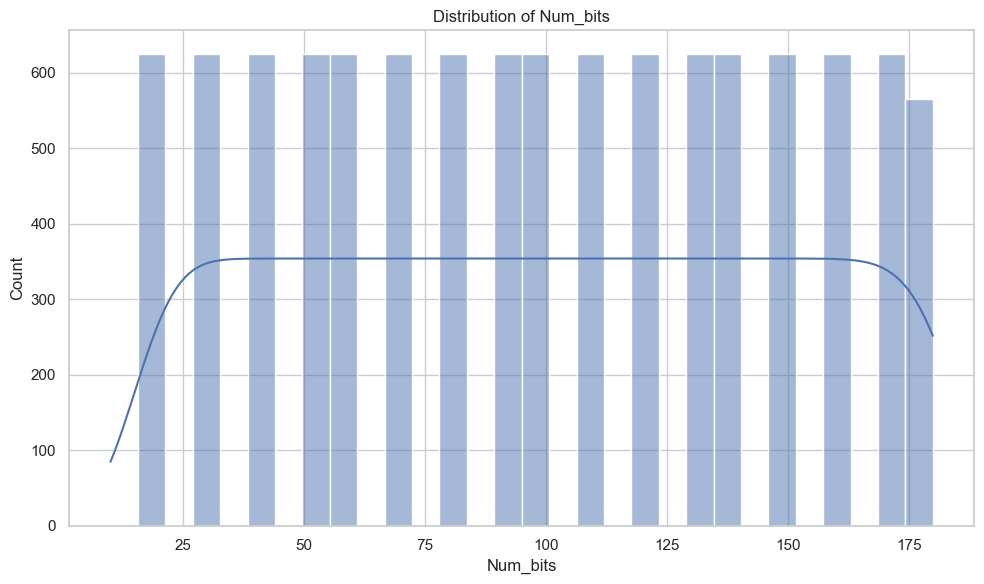

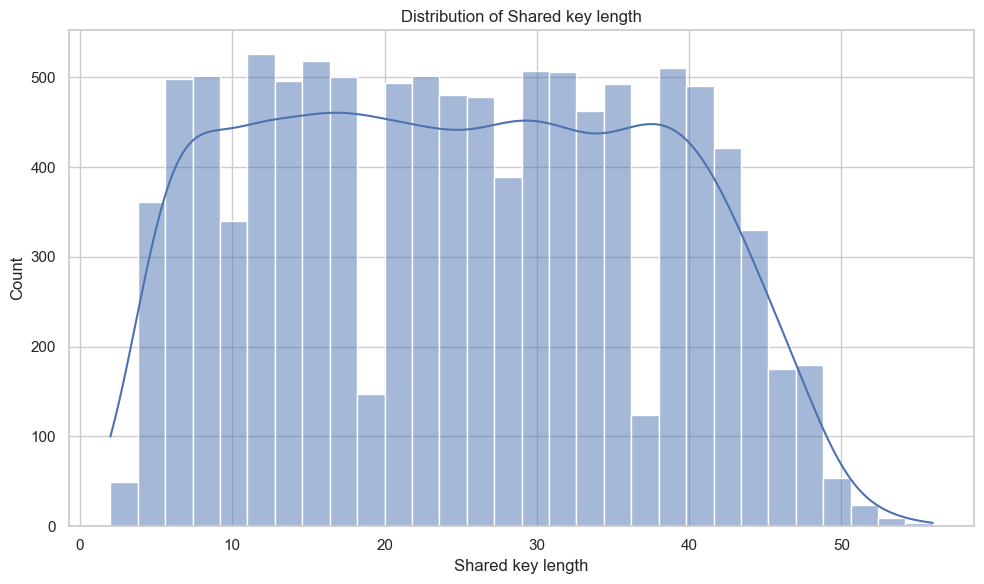

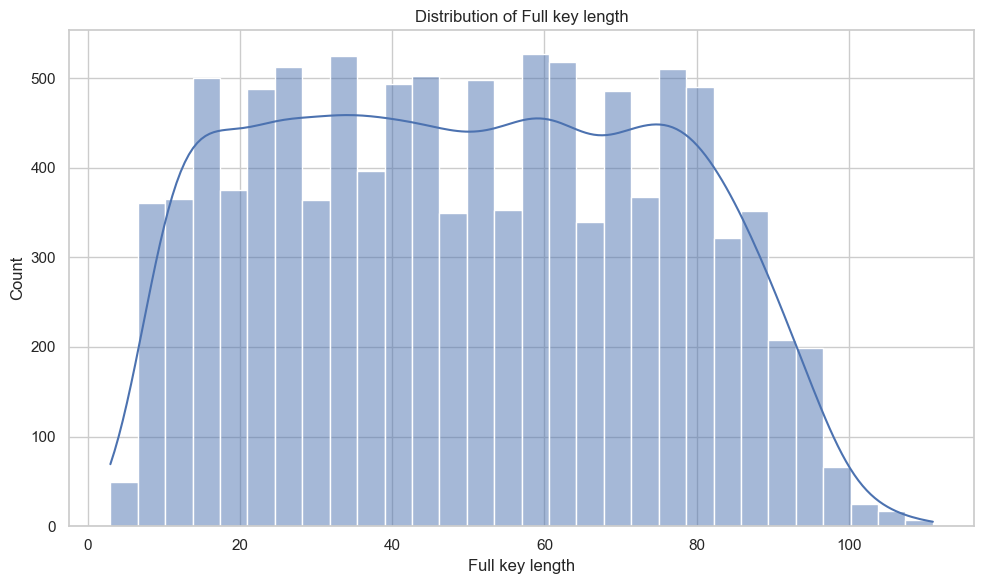

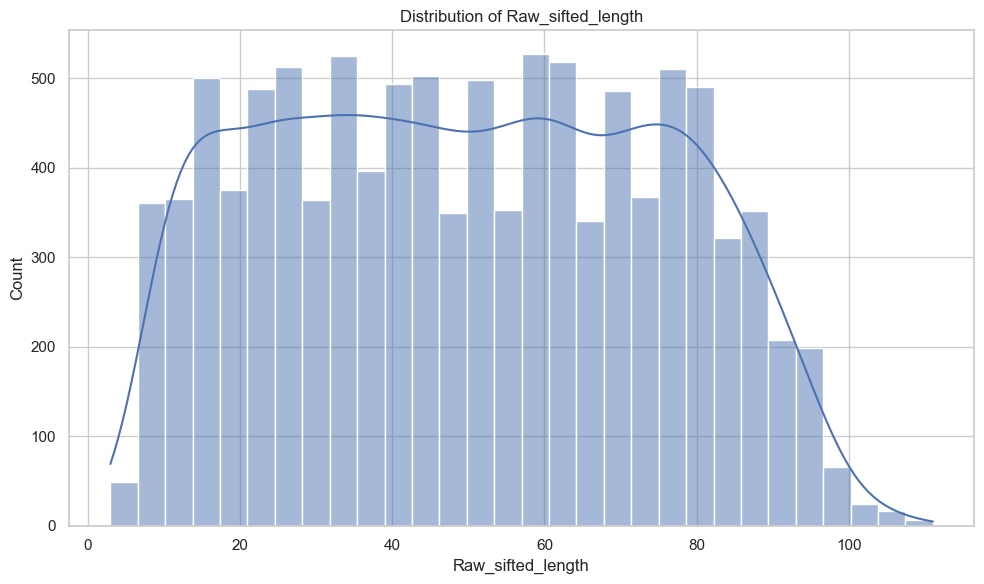

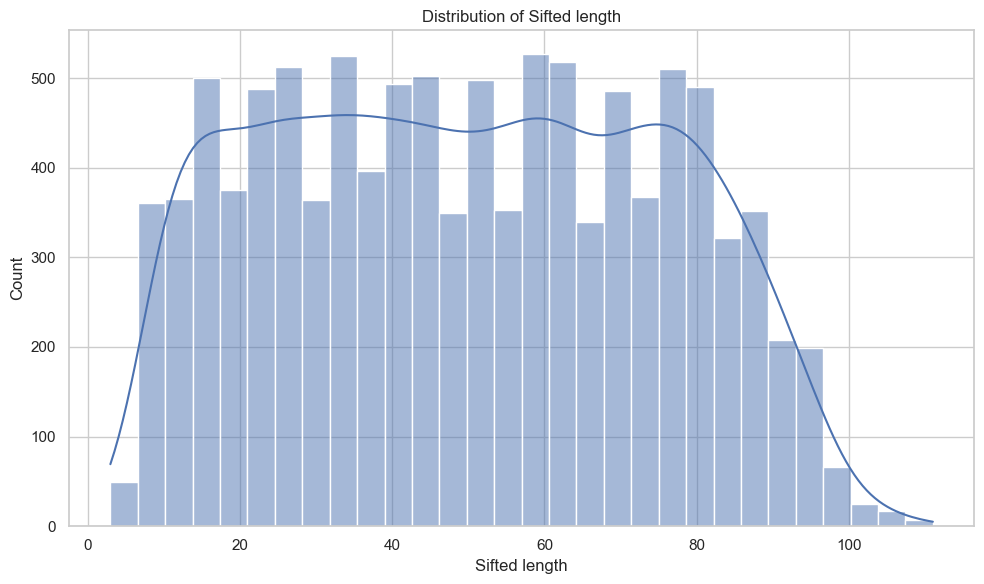

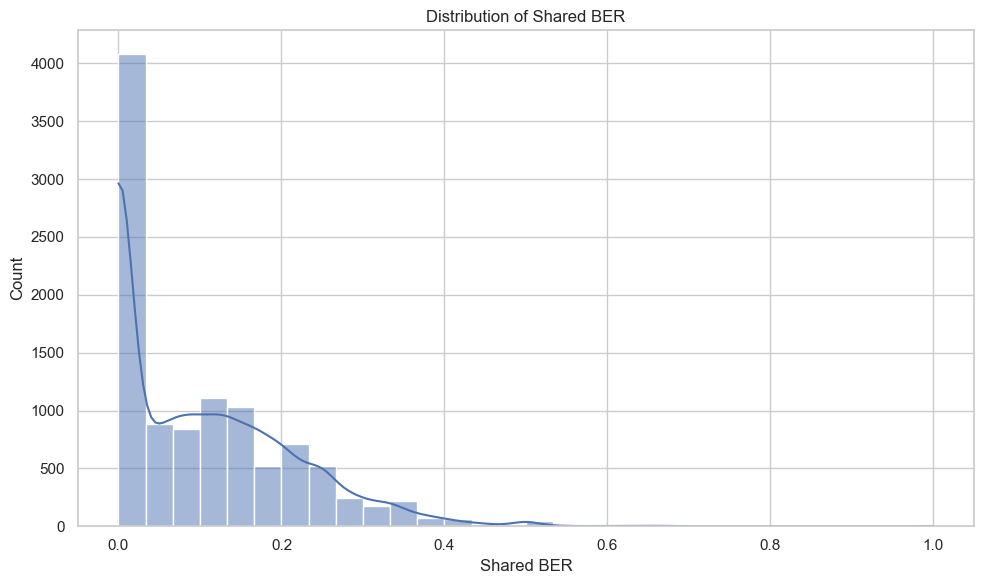

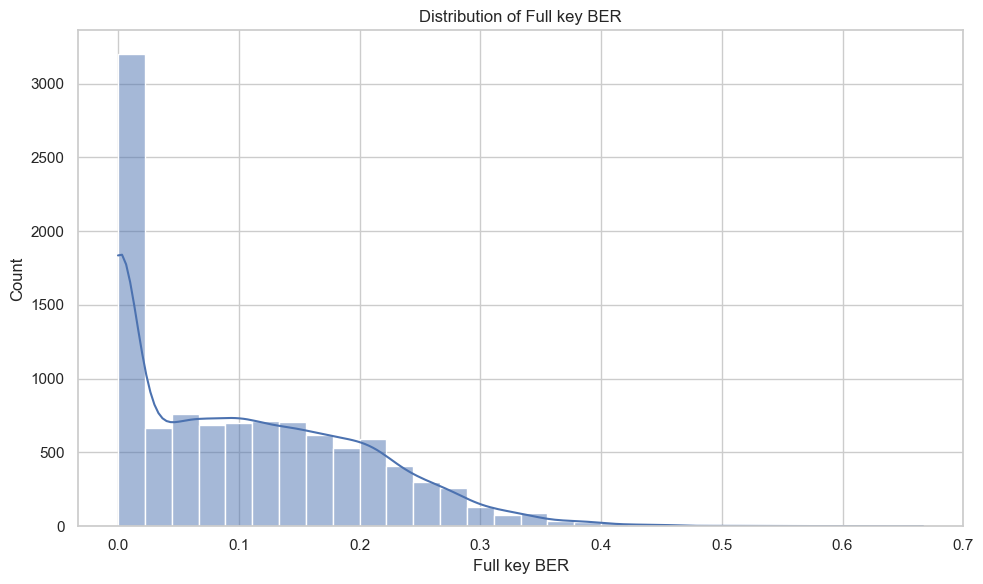

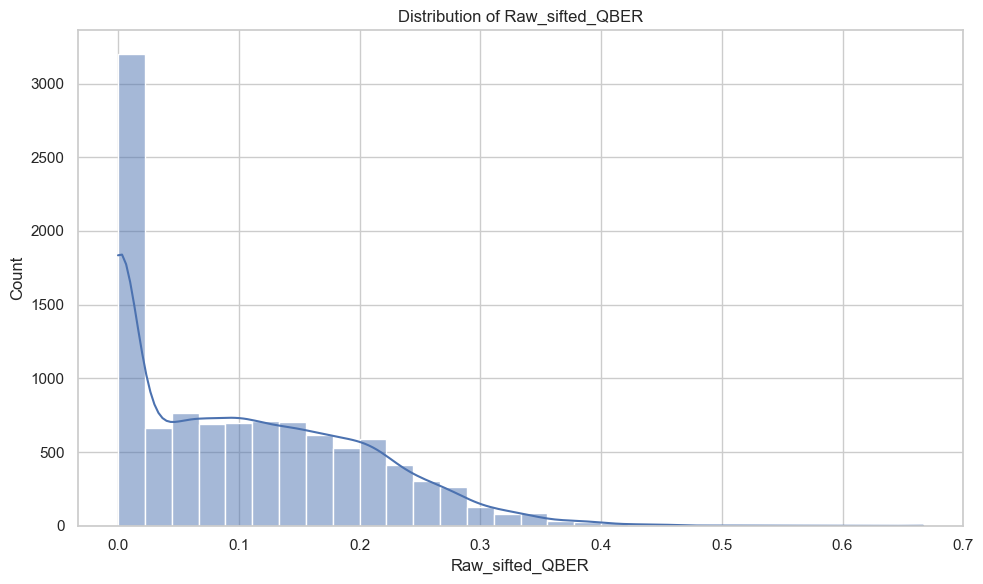

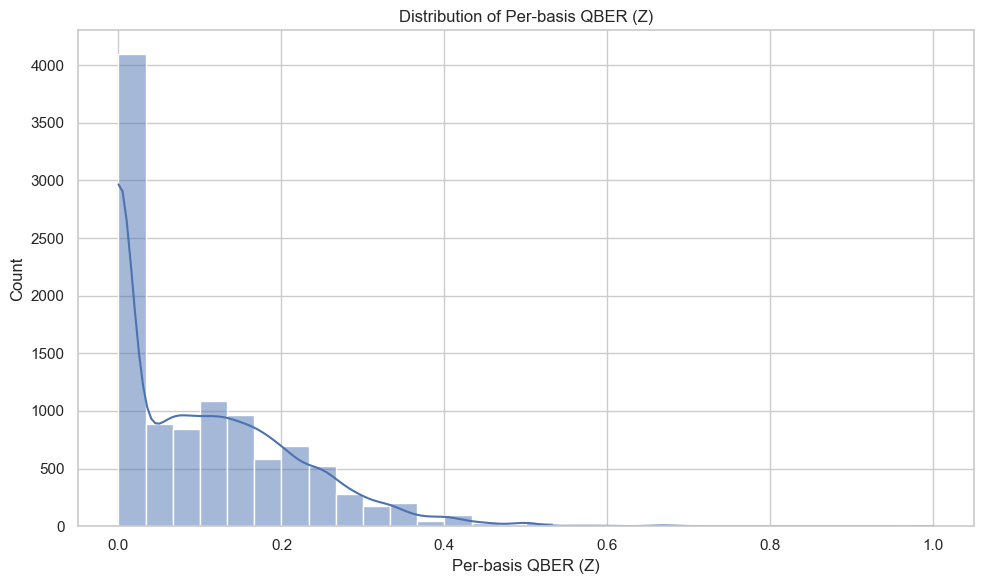

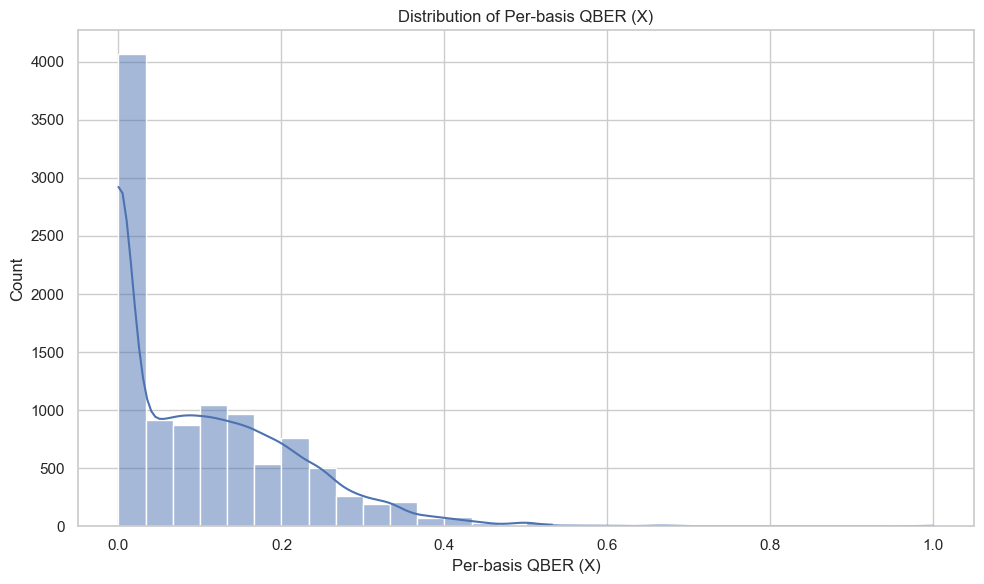

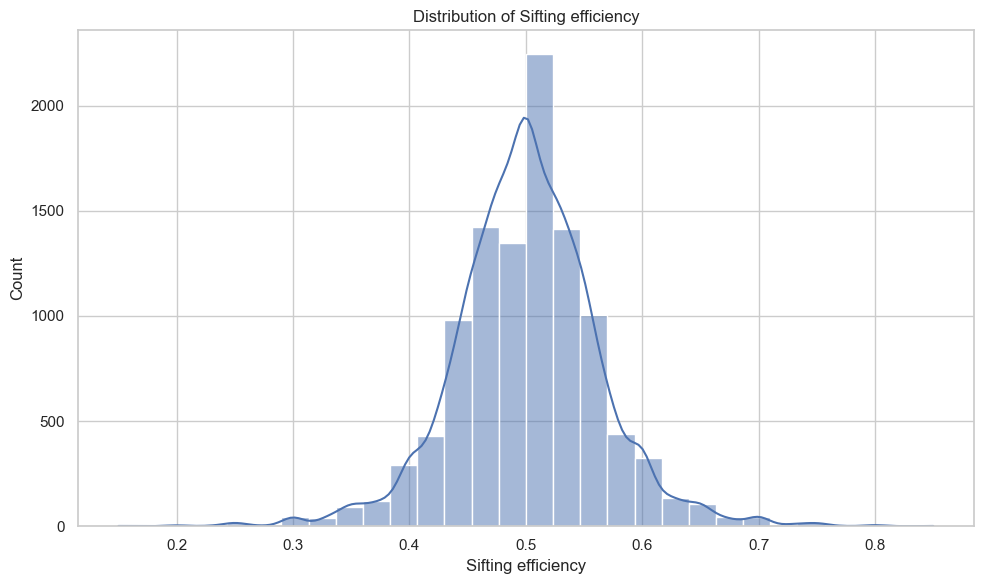

Saved plots: ['./data\\ml_outputs\\hist_Num_bits.png', './data\\ml_outputs\\hist_Shared_key_length.png', './data\\ml_outputs\\hist_Full_key_length.png', './data\\ml_outputs\\hist_Raw_sifted_length.png', './data\\ml_outputs\\hist_Sifted_length.png', './data\\ml_outputs\\hist_Shared_BER.png', './data\\ml_outputs\\hist_Full_key_BER.png', './data\\ml_outputs\\hist_Raw_sifted_QBER.png', './data\\ml_outputs\\hist_Per-basis_QBER_(Z).png', './data\\ml_outputs\\hist_Per-basis_QBER_(X).png', './data\\ml_outputs\\hist_Sifting_efficiency.png']


<Figure size 1000x600 with 0 Axes>

In [10]:
plots = []
def save_show(ax, title, fname):
    ax.set_title(title)
    plt.tight_layout()
    path = os.path.join(OUT_DIR, fname)
    plt.savefig(path)
    plots.append(path)
    plt.show()

# Histogram helper
def hist_col(col, bins=30):
    if col in df.columns and df[col].notna().sum() > 0:
        ax = sns.histplot(df[col].dropna(), kde=True, bins=bins)
        save_show(ax, f'Distribution of {col}', f"hist_{col.replace(' ', '_')}.png")
        plt.clf()

for col in ['Num_bits','Shared key length','Full key length','Raw_sifted_length','Sifted length']:
    hist_col(col)

for col in ['Shared BER','Full key BER','Raw_sifted_QBER','Per-basis QBER (Z)','Per-basis QBER (X)']:
    hist_col(col)

hist_col('Sifting efficiency')
print('Saved plots:', plots)

## Relationships: QBER vs Interception Density, Backend Effects

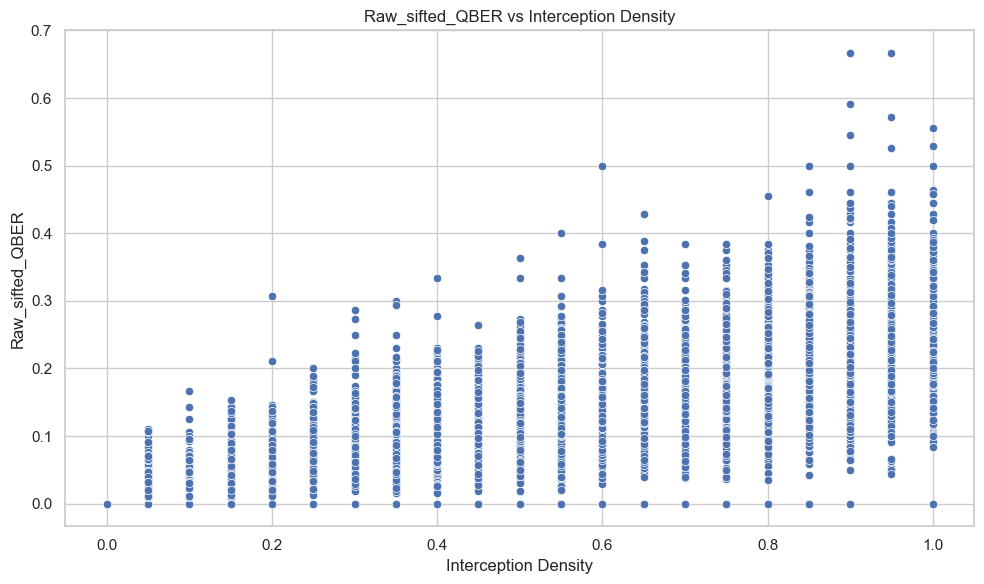

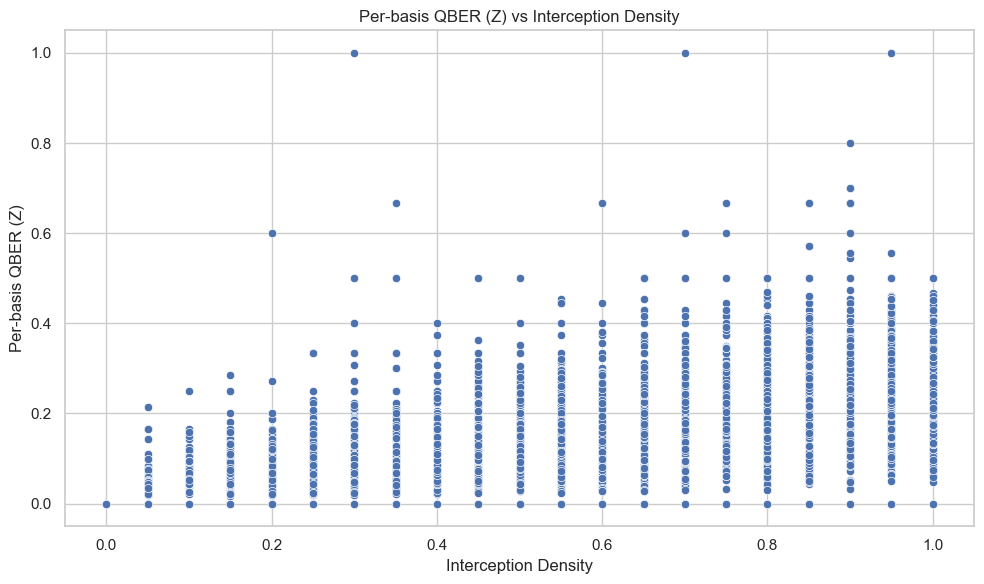

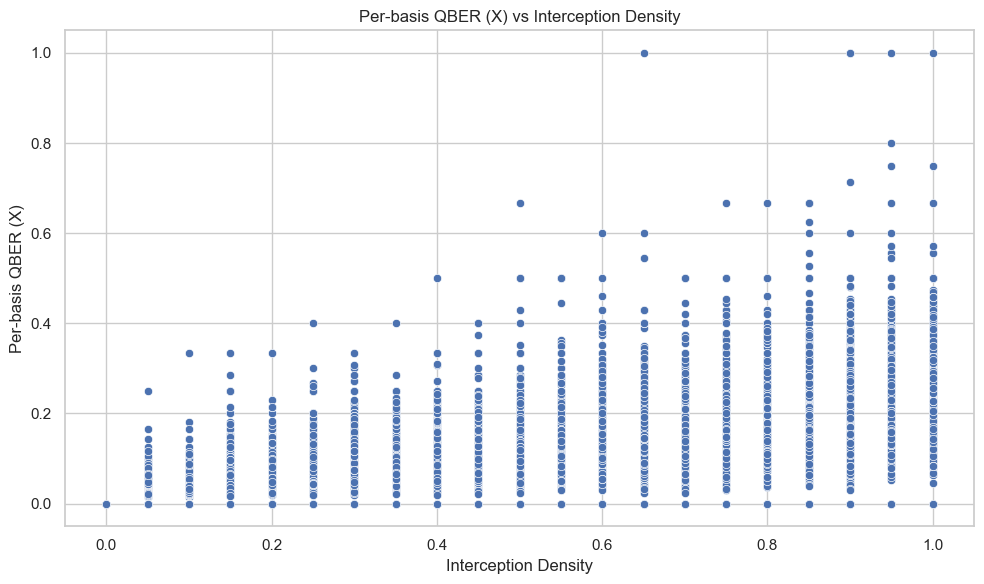

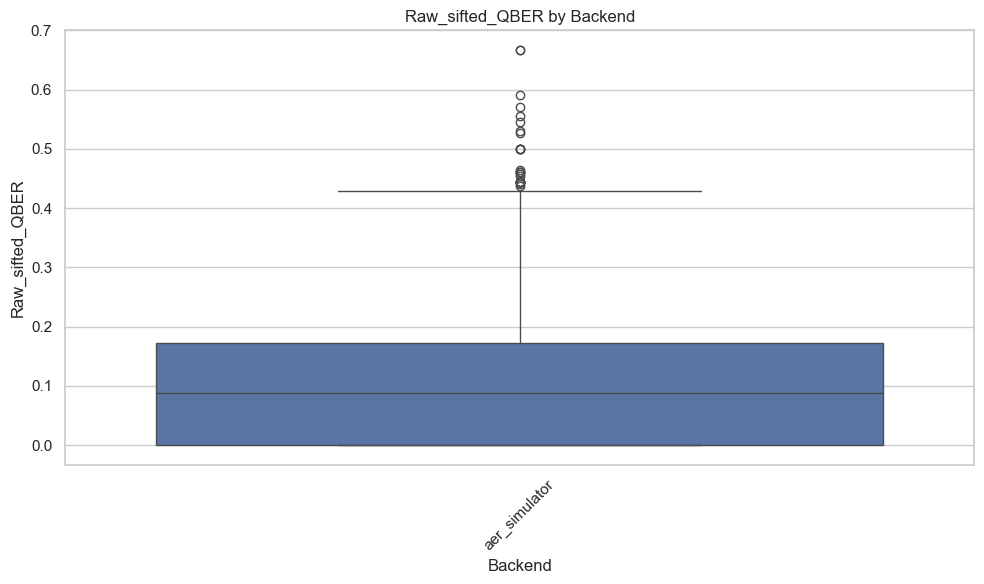

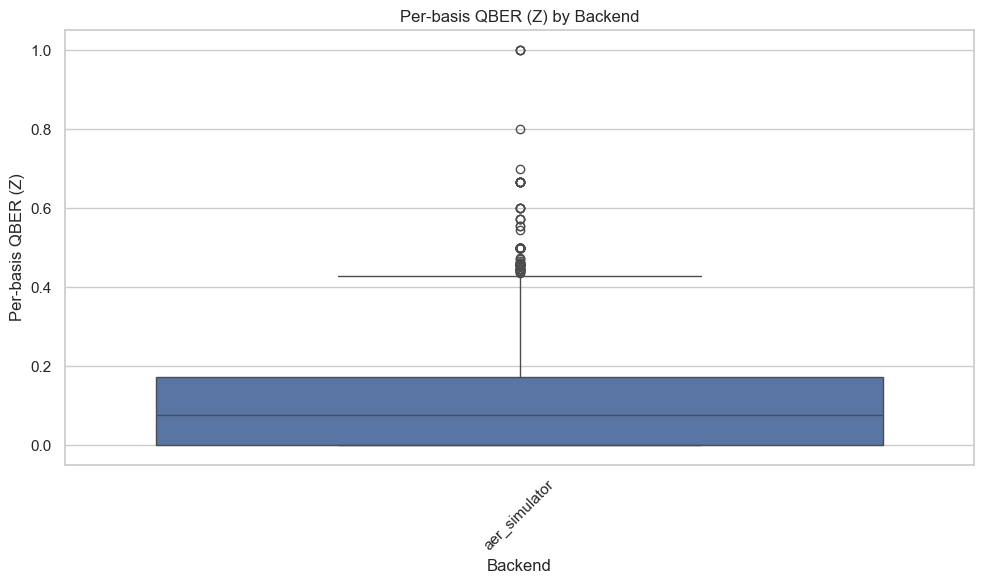

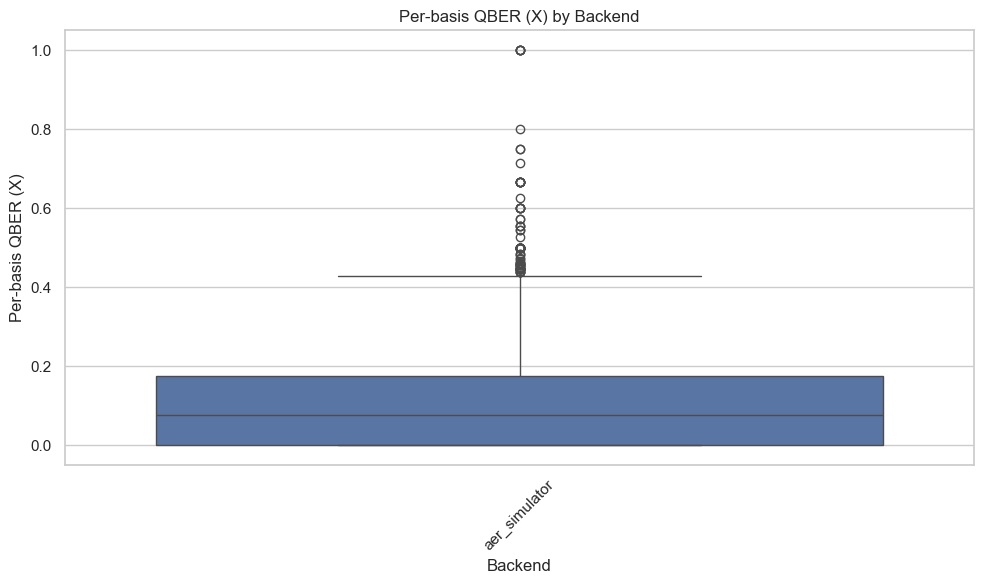

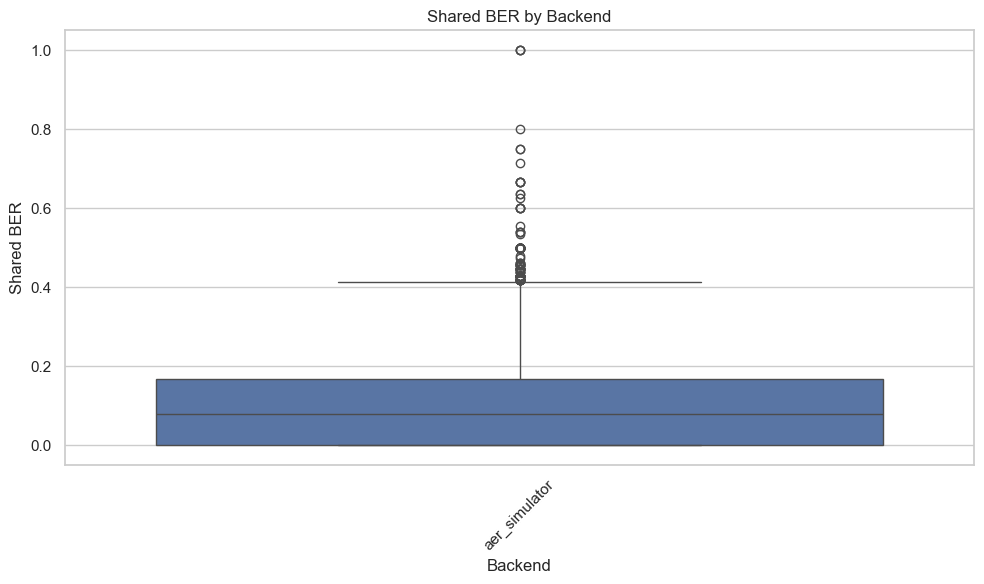

<Figure size 1000x600 with 0 Axes>

In [31]:
# Scatter QBER vs Interception Density
def scatter_xy(xcol, ycol):
    cols = [xcol, ycol]
    if all(c in df.columns for c in cols):
        d = df[[xcol, ycol]].dropna()
        if len(d) > 0:
            ax = sns.scatterplot(data=d, x=xcol, y=ycol)
            title = f'{ycol} vs {xcol}'
            fname = f"scatter_{ycol.replace(' ', '_')}_vs_{xcol.replace(' ', '_')}.png"
            save_show(ax, title, fname)
            plt.clf()

scatter_xy('Interception Density','Raw_sifted_QBER')
scatter_xy('Interception Density','Per-basis QBER (Z)')
scatter_xy('Interception Density','Per-basis QBER (X)')

# Boxplot of QBER by Backend
def boxplot_by_backend(col):
    if 'Backend' in df.columns and col in df.columns:
        d = df[['Backend', col]].dropna()
        if len(d) > 0:
            ax = sns.boxplot(data=d, x='Backend', y=col)
            ax.tick_params(axis='x', rotation=45)
            fname = f"box_{col.replace(' ', '_')}_by_backend.png"
            save_show(ax, f'{col} by Backend', fname)
            plt.clf()

for col in ['Raw_sifted_QBER','Per-basis QBER (Z)','Per-basis QBER (X)','Shared BER']:
    boxplot_by_backend(col)

## Preliminary Feature Importance (Attack label)

Model dataset shape: (10566, 9)
              precision    recall  f1-score   support

           0       0.75      0.99      0.85       531
           1       1.00      0.92      0.96      2111

    accuracy                           0.93      2642
   macro avg       0.87      0.95      0.91      2642
weighted avg       0.95      0.93      0.94      2642

ROC-AUC: 0.9743478916374726
              precision    recall  f1-score   support

           0       0.75      0.99      0.85       531
           1       1.00      0.92      0.96      2111

    accuracy                           0.93      2642
   macro avg       0.87      0.95      0.91      2642
weighted avg       0.95      0.93      0.94      2642

ROC-AUC: 0.9743478916374726


Per-basis QBER (Z)    3.349053e-01
Per-basis QBER (X)    3.124121e-01
Shared BER            3.085349e-01
Raw_sifted_length     1.475790e-02
Sifting efficiency    1.214765e-02
Shared key length     9.370308e-03
Num_bits              7.871840e-03
ech                   1.921181e-14
Backend_cat           0.000000e+00
dtype: float64

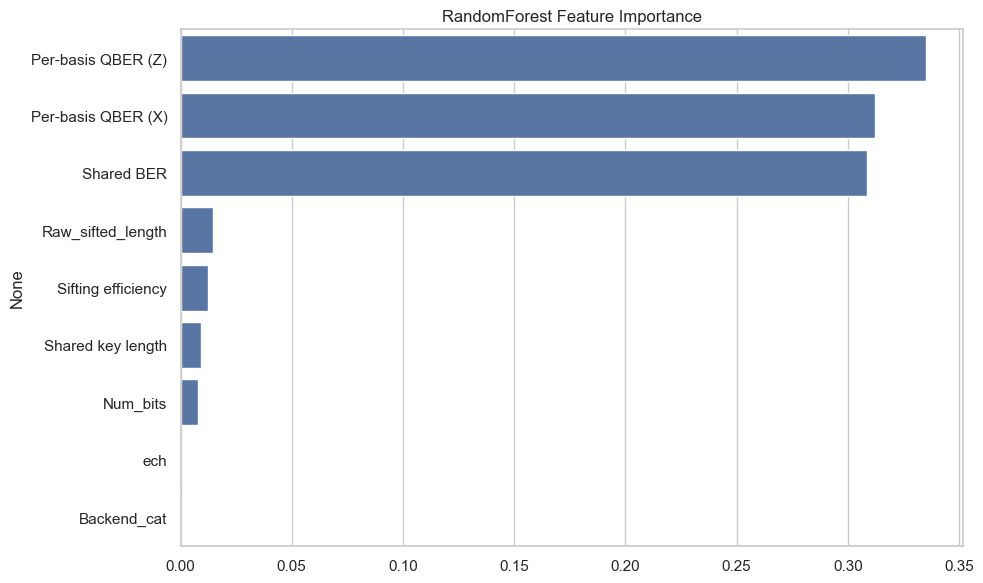

Per-basis QBER (X)    0.096480
Per-basis QBER (Z)    0.096215
Shared BER            0.088002
Sifting efficiency    0.001249
Raw_sifted_length     0.000946
Backend_cat           0.000000
ech                   0.000000
Shared key length    -0.000757
Num_bits             -0.001173
dtype: float64

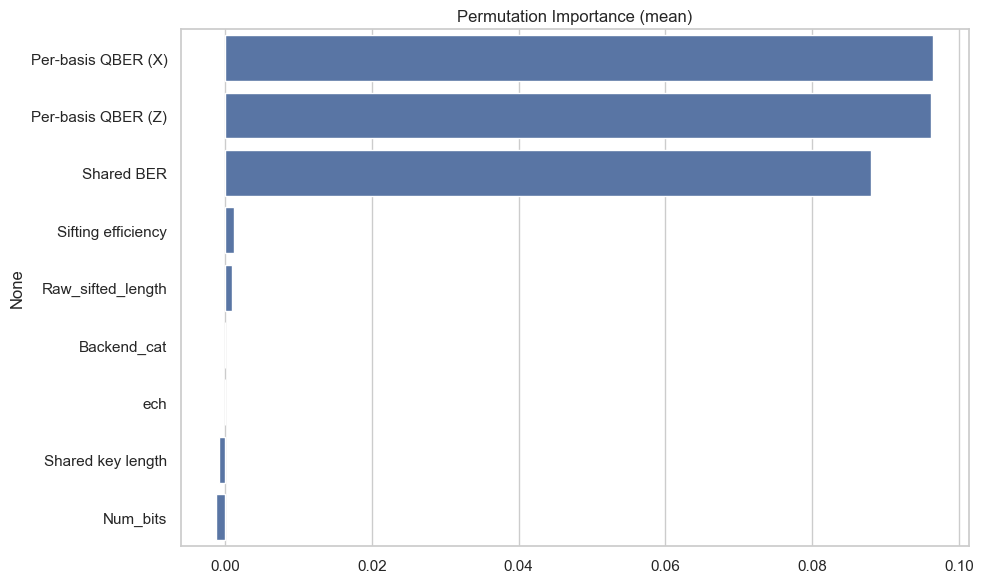

<Figure size 1000x600 with 0 Axes>

In [36]:
# Select realistic, non-oracle features
feature_cols = [
    'Shared BER','Shared key length','Raw_sifted_length','Sifting efficiency',
    'Per-basis QBER (Z)','Per-basis QBER (X)','ech','Num_bits'
]

# Include backend as category if present
if 'Backend' in df.columns:
    df['Backend_cat'] = df['Backend'].astype('category').cat.codes
    feature_cols.append('Backend_cat')

# Drop rows with missing target
df_model = df.dropna(subset=['Attack label'])
y = df_model['Attack label'].astype(int)
X = df_model[feature_cols].copy()

# Cast to numeric
for c in feature_cols:
    X[c] = pd.to_numeric(X[c], errors='coerce')

# Drop rows with missing features
mask = X.notna().all(axis=1)
X = X[mask]
y = y[mask]
print('Model dataset shape:', X.shape)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42, stratify=y)
clf = RandomForestClassifier(n_estimators=300, random_state=42, class_weight='balanced')
clf.fit(X_train, y_train)

y_pred = clf.predict(X_test)
y_proba = clf.predict_proba(X_test)[:,1] if hasattr(clf, 'predict_proba') else None
print(classification_report(y_test, y_pred))
if y_proba is not None:
    print('ROC-AUC:', roc_auc_score(y_test, y_proba))

# Feature importances
imp = pd.Series(clf.feature_importances_, index=feature_cols).sort_values(ascending=False)
display(imp)
ax = sns.barplot(x=imp.values, y=imp.index)
save_show(ax, 'RandomForest Feature Importance', 'rf_feature_importance.png')
plt.clf()

# Permutation importance
perm = permutation_importance(clf, X_test, y_test, n_repeats=10, random_state=42)
perm_imp = pd.Series(perm.importances_mean, index=feature_cols).sort_values(ascending=False)
display(perm_imp)
ax = sns.barplot(x=perm_imp.values, y=perm_imp.index)
save_show(ax, 'Permutation Importance (mean)', 'perm_importance.png')
plt.clf()

## SHAP Summary (if available)

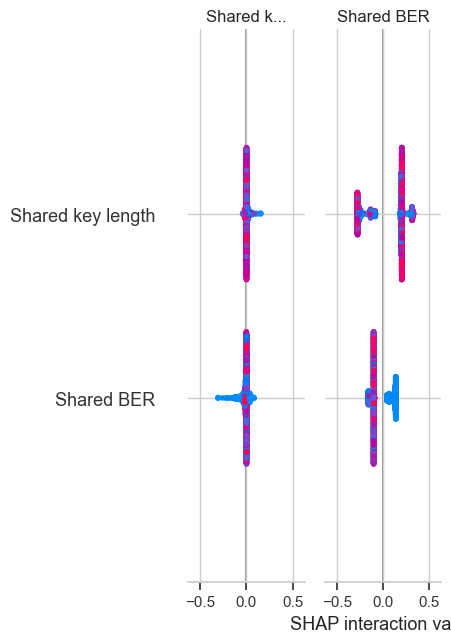

In [37]:
if HAS_SHAP:
    explainer = shap.TreeExplainer(clf)
    shap_values = explainer.shap_values(X_test)
    # Binary classifier returns list; pick class 1
    sv = shap_values[1] if isinstance(shap_values, list) and len(shap_values) > 1 else shap_values
    shap.summary_plot(sv, X_test, feature_names=X_test.columns, show=False)
    plt.tight_layout()
    path = os.path.join(OUT_DIR, 'shap_summary.png')
    plt.savefig(path)
    plt.show()
else:
    print('SHAP not installed; skipping SHAP plots.')

## Secure Interchanges by Number of Bits
We study how often an interchange is marked as secure across different `Num_bits` values, using the `Result` column. We compute counts and secure rates, then visualize them.

In [13]:
# Prepare 'Result' normalized and compute secure stats by Num_bits
df_bits = df.copy()
if 'Result' in df_bits.columns:
    # Normalize to string and lower for robust matching
    df_bits['Result_norm'] = df_bits['Result'].astype('string').str.strip().str.lower()
else:
    raise KeyError("Column 'Result' not found in the dataset.")

if 'Num_bits' not in df_bits.columns:
    raise KeyError("Column 'Num_bits' not found in the dataset.")

# Drop rows without Num_bits
df_bits = df_bits.dropna(subset=['Num_bits'])
df_bits['Num_bits'] = pd.to_numeric(df_bits['Num_bits'], errors='coerce')
df_bits = df_bits.dropna(subset=['Num_bits'])

# Define secure labels to match
secure_labels = {'secure','ok','success'}  # extend as needed based on dataset semantics

df_bits['is_secure'] = df_bits['Result_norm'].isin(secure_labels)

by_bits = (
    df_bits.groupby('Num_bits').agg(
        total=('Result_norm','size'),
        secure=('is_secure','sum')
    ).reset_index()
)
by_bits['secure_rate'] = by_bits['secure'] / by_bits['total']

display(by_bits.sort_values('Num_bits'))

# Save table to CSV
table_path = os.path.join(OUT_DIR, 'secure_by_bits.csv')
by_bits.sort_values('Num_bits').to_csv(table_path, index=False)
print('Saved table:', table_path)

,Num_bits,total,secure,secure_rate
0,10.0,1,0,0.000000
1,20.0,625,305,0.488000
2,30.0,625,246,0.393600
3,40.0,625,204,0.326400
4,50.0,625,194,0.310400
5,60.0,625,177,0.283200
6,70.0,625,172,0.275200
7,80.0,625,166,0.265600
8,90.0,625,155,0.248000
9,100.0,625,154,0.246400


Saved table: ./data\ml_outputs\secure_by_bits.csv


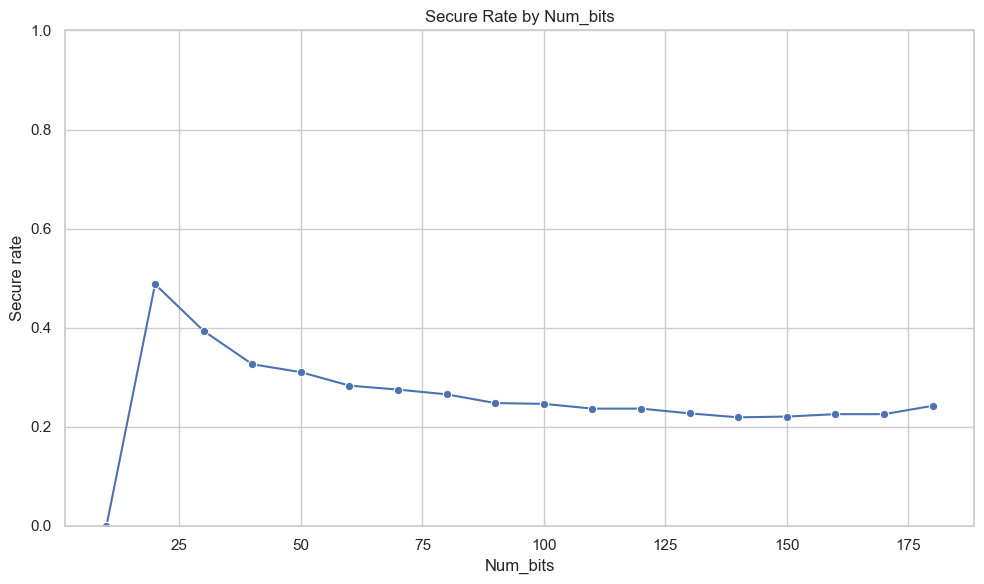

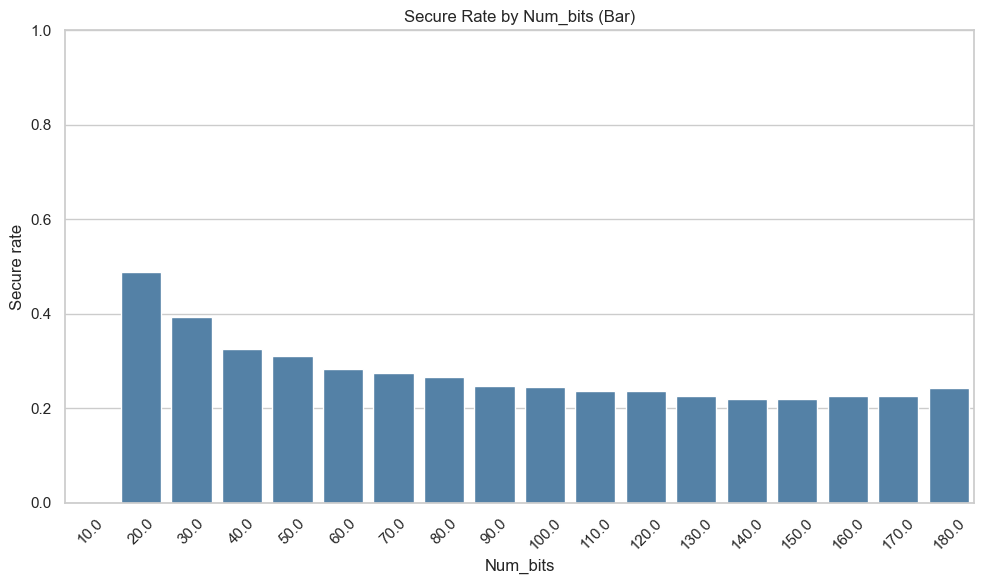

<Figure size 1000x600 with 0 Axes>

In [14]:
# Plot secure percentage by Num_bits
if len(by_bits) > 0:
    ax = sns.lineplot(data=by_bits.sort_values('Num_bits'), x='Num_bits', y='secure_rate', marker='o')
    ax.set_ylim(0, 1)
    ax.set_ylabel('Secure rate')
    save_show(ax, 'Secure Rate by Num_bits', 'secure_rate_by_bits_line.png')
    plt.clf()

    ax = sns.barplot(data=by_bits.sort_values('Num_bits'), x='Num_bits', y='secure_rate', color='steelblue')
    ax.set_ylim(0, 1)
    ax.set_ylabel('Secure rate')
    ax.tick_params(axis='x', rotation=45)
    save_show(ax, 'Secure Rate by Num_bits (Bar)', 'secure_rate_by_bits_bar.png')
    plt.clf()
else:
    print('No data available to plot secure rate by Num_bits.')

## False Positives by Number of Bits
We define a false positive here as rows with `Attack label` == 1 (attack present) while `Result` indicates a secure interchange. We compute counts and rates per `Num_bits` and visualize them.

In [15]:
# Compute false positives per Num_bits
# Criteria: Attack label == 1 and Result indicates secure
fp_df = df.copy()

# Normalize and cast
fp_df['Result_norm'] = fp_df['Result'].astype('string').str.strip().str.lower() if 'Result' in fp_df.columns else pd.Series(dtype='string')
fp_df['Attack label'] = pd.to_numeric(fp_df['Attack label'], errors='coerce') if 'Attack label' in fp_df.columns else pd.Series(dtype='float')
fp_df['Num_bits'] = pd.to_numeric(fp_df['Num_bits'], errors='coerce') if 'Num_bits' in fp_df.columns else pd.Series(dtype='float')

# Define secure labels including common misspellings
secure_labels = {'secure','ok','success'}

# Filter usable rows
fp_df = fp_df.dropna(subset=['Num_bits','Attack label','Result_norm'])

# Identify false positives
fp_df['is_secure'] = fp_df['Result_norm'].isin(secure_labels)
fp_df['is_fp'] = (fp_df['Attack label'] == 1) & (fp_df['is_secure'])

# Aggregate by Num_bits
fp_by_bits = (
    fp_df.groupby('Num_bits').agg(
        total=('Result_norm','size'),
        attacks=('Attack label', lambda s: int((s == 1).sum())),
        false_positives=('is_fp','sum')
    ).reset_index()
)
fp_by_bits['fp_rate_over_total'] = fp_by_bits['false_positives'] / fp_by_bits['total']
fp_by_bits['fp_rate_over_attacks'] = fp_by_bits.apply(lambda r: (r['false_positives'] / r['attacks']) if r['attacks'] > 0 else 0.0, axis=1)

display(fp_by_bits.sort_values('Num_bits'))

# Save table
fp_table_path = os.path.join(OUT_DIR, 'false_positives_by_bits.csv')
fp_by_bits.sort_values('Num_bits').to_csv(fp_table_path, index=False)
print('Saved table:', fp_table_path)

,Num_bits,total,attacks,false_positives,fp_rate_over_total,fp_rate_over_attacks
0,10.0,1,1,0,0.000000,0.000000
1,20.0,625,500,180,0.288000,0.360000
2,30.0,625,500,121,0.193600,0.242000
3,40.0,625,500,79,0.126400,0.158000
4,50.0,625,500,69,0.110400,0.138000
5,60.0,625,500,52,0.083200,0.104000
6,70.0,625,500,47,0.075200,0.094000
7,80.0,625,500,41,0.065600,0.082000
8,90.0,625,500,30,0.048000,0.060000
9,100.0,625,500,29,0.046400,0.058000


Saved table: ./data\ml_outputs\false_positives_by_bits.csv


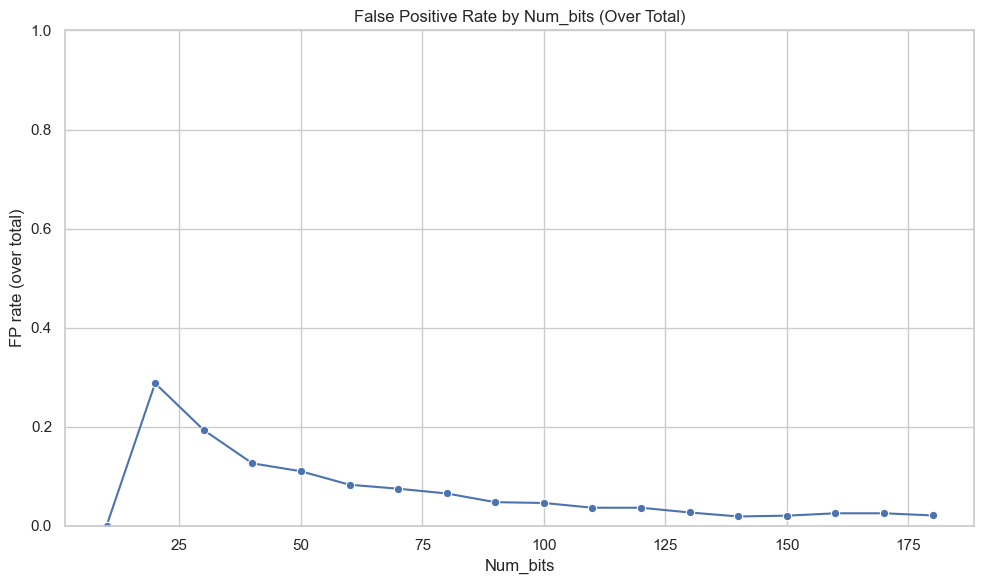

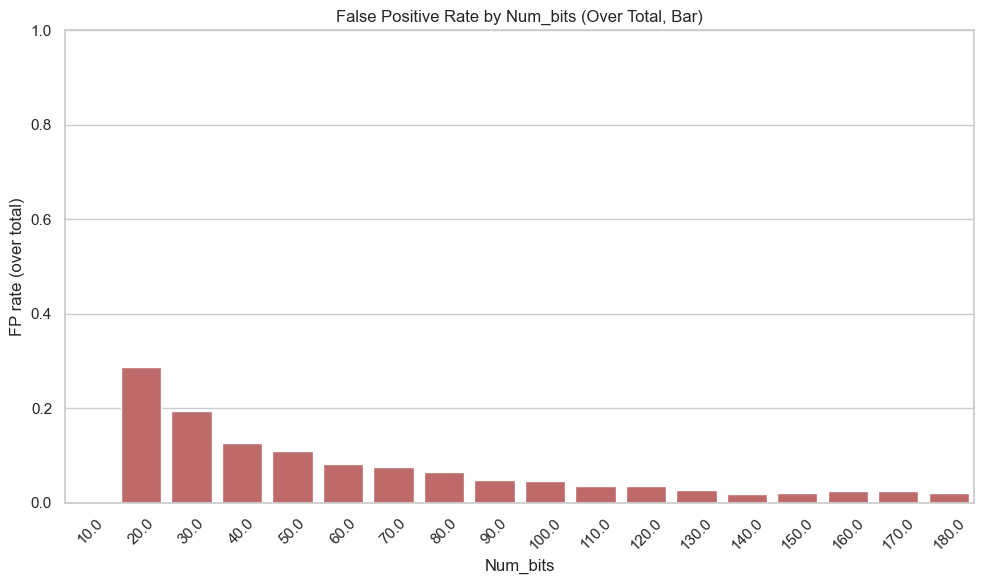

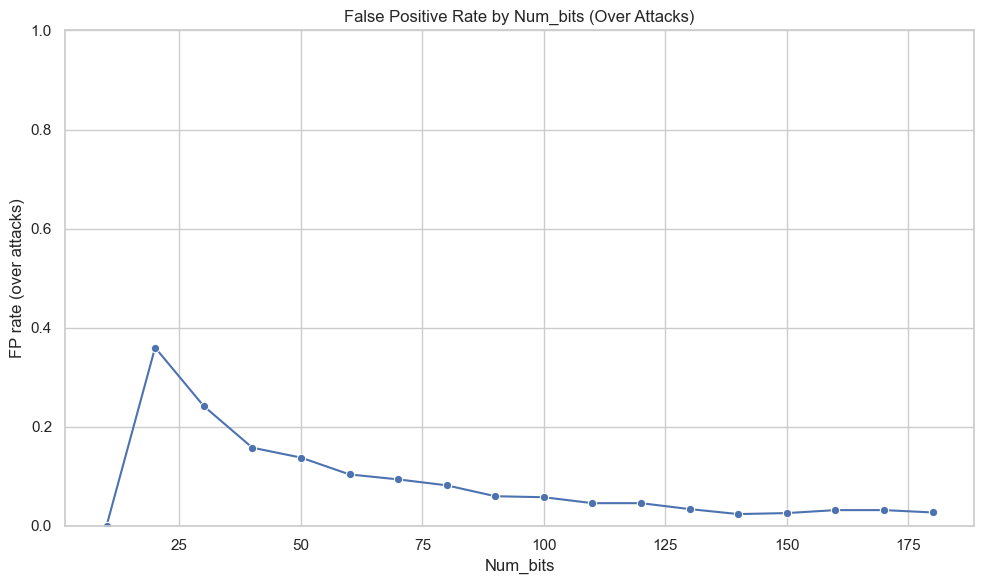

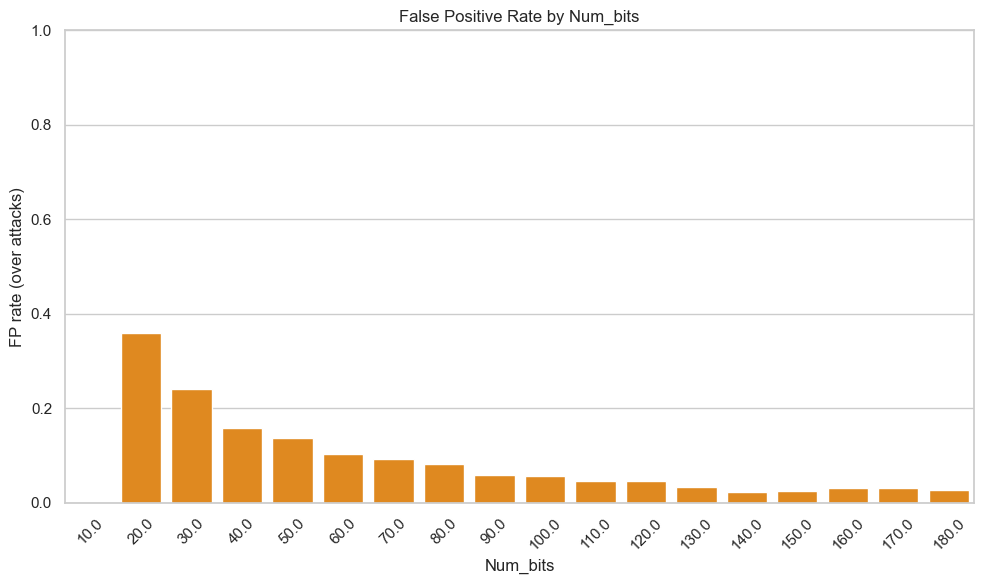

<Figure size 1000x600 with 0 Axes>

In [33]:
# Plot false positive rates by Num_bits
if len(fp_by_bits) > 0:
    # Over total rows
    ax = sns.lineplot(data=fp_by_bits.sort_values('Num_bits'), x='Num_bits', y='fp_rate_over_total', marker='o')
    ax.set_ylim(0, 1)
    ax.set_ylabel('FP rate (over total)')
    save_show(ax, 'False Positive Rate by Num_bits (Over Total)', 'fp_rate_over_total_by_bits_line.png')
    plt.clf()

    ax = sns.barplot(data=fp_by_bits.sort_values('Num_bits'), x='Num_bits', y='fp_rate_over_total', color='indianred')
    ax.set_ylim(0, 1)
    ax.set_ylabel('FP rate (over total)')
    ax.tick_params(axis='x', rotation=45)
    save_show(ax, 'False Positive Rate by Num_bits (Over Total, Bar)', 'fp_rate_over_total_by_bits_bar.png')
    plt.clf()

    # Over attacks only
    ax = sns.lineplot(data=fp_by_bits.sort_values('Num_bits'), x='Num_bits', y='fp_rate_over_attacks', marker='o')
    ax.set_ylim(0, 1)
    ax.set_ylabel('FP rate (over attacks)')
    save_show(ax, 'False Positive Rate by Num_bits (Over Attacks)', 'fp_rate_over_attacks_by_bits_line.png')
    plt.clf()

    ax = sns.barplot(data=fp_by_bits.sort_values('Num_bits'), x='Num_bits', y='fp_rate_over_attacks', color='darkorange')
    ax.set_ylim(0, 1)
    ax.set_ylabel('FP rate (over attacks)')
    ax.tick_params(axis='x', rotation=45)
    save_show(ax, 'False Positive Rate by Num_bits', 'fp_rate_over_attacks_by_bits_bar.png')
    plt.clf()
else:
    print('No data available to plot false positive rates by Num_bits.')

## QBER Threshold vs Reported Security
We compare the standard BB84 QBER threshold decision (default 11%) against the dataset's reported security (`Result`). We:
- Pick a QBER column (preferring `Raw_sifted_QBER`, then `Shared BER`, then `Full key BER`).
- Flag rows with QBER strictly above the threshold as over-threshold.
- Normalize `Result` and identify rows marked as secure.
- Count and visualize cases where QBER > threshold but `Result` is secure, and provide overall confusion-style counts and per-`Num_bits` breakdowns.

Using QBER column: Raw_sifted_QBER; Threshold: 11.00%


,metric,value
0,total_analyzed,10567
1,over_threshold_and_secure,0
2,under_threshold_and_secure,2905
3,over_threshold_and_insecure,4553
4,under_threshold_and_insecure,3109


result_secure,False,True
threshold_secure,,
False,4553,0
True,3109,2905


Saved: ./data\ml_outputs\qber_threshold_vs_result_summary.csv
Saved: ./data\ml_outputs\qber_threshold_vs_result_confusion.csv


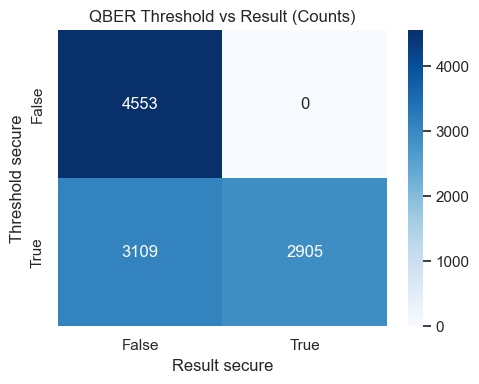

<Figure size 1000x600 with 0 Axes>

In [17]:
# Overall summary: QBER threshold vs Result
THRESHOLD = 0.11  # 11%

# Choose a QBER column with sensible default ordering
qber_candidates = ['Raw_sifted_QBER', 'Shared BER', 'Full key BER']
avail_qber = [c for c in qber_candidates if c in df.columns]
if not avail_qber:
    raise KeyError("No QBER-like column found. Expected one of: %s" % qber_candidates)
QBER_COL = avail_qber[0]

thr_df = df.copy()
thr_df[QBER_COL] = pd.to_numeric(thr_df[QBER_COL], errors='coerce')

# Normalize Result and flag secure labels (include common variants/typos)
thr_df['Result_norm'] = thr_df['Result'].astype('string').str.strip().str.lower() if 'Result' in thr_df.columns else pd.Series(dtype='string')
secure_labels = {'secure','segure','ok','success'}
thr_df['is_secure'] = thr_df['Result_norm'].isin(secure_labels)

# Keep rows with a defined QBER value
thr_df = thr_df.dropna(subset=[QBER_COL])

# Over-threshold if strictly greater than threshold
thr_df['qber_over'] = thr_df[QBER_COL] > THRESHOLD

# Key counts
total_rows = len(thr_df)
over_and_secure = int(((thr_df['qber_over']) & (thr_df['is_secure'])).sum())
under_and_secure = int(((~thr_df['qber_over']) & (thr_df['is_secure'])).sum())
over_and_insecure = int(((thr_df['qber_over']) & (~thr_df['is_secure'])).sum())
under_and_insecure = int(((~thr_df['qber_over']) & (~thr_df['is_secure'])).sum())

summary_df = pd.DataFrame({
    'metric': [
        'total_analyzed',
        'over_threshold_and_secure',
        'under_threshold_and_secure',
        'over_threshold_and_insecure',
        'under_threshold_and_insecure'
    ],
    'value': [
        total_rows,
        over_and_secure,
        under_and_secure,
        over_and_insecure,
        under_and_insecure
    ]
})

# Confusion-like table: rows = Threshold decision, cols = Result marked secure
ct = pd.crosstab(index=(~thr_df['qber_over']).rename('threshold_secure'),
                 columns=thr_df['is_secure'].rename('result_secure'))

print(f"Using QBER column: {QBER_COL}; Threshold: {THRESHOLD:.2%}")
display(summary_df)
display(ct)

# Save artifacts
summary_path = os.path.join(OUT_DIR, 'qber_threshold_vs_result_summary.csv')
confusion_path = os.path.join(OUT_DIR, 'qber_threshold_vs_result_confusion.csv')
summary_df.to_csv(summary_path, index=False)
ct.to_csv(confusion_path)
print('Saved:', summary_path)
print('Saved:', confusion_path)

# Plot confusion heatmap
plt.figure(figsize=(5,4))
ax = sns.heatmap(ct, annot=True, fmt='d', cmap='Blues')
ax.set_title('Threshold vs Result (counts)')
ax.set_xlabel('Result secure')
ax.set_ylabel('Threshold secure')
save_show(ax, 'QBER Threshold vs Result (Counts)', 'qber_threshold_confusion_heatmap.png')
plt.clf()

,Num_bits,total,over,secure,over_and_secure,over_rate,secure_rate,over_and_secure_rate_over_total,over_and_secure_share_of_secure
0,10.0,1,1,0,0,1.000000,0.000000,0.0,0.0
1,20.0,625,229,305,0,0.366400,0.488000,0.0,0.0
2,30.0,625,250,246,0,0.400000,0.393600,0.0,0.0
3,40.0,625,267,204,0,0.427200,0.326400,0.0,0.0
4,50.0,625,274,194,0,0.438400,0.310400,0.0,0.0
5,60.0,625,278,177,0,0.444800,0.283200,0.0,0.0
6,70.0,625,278,172,0,0.444800,0.275200,0.0,0.0
7,80.0,625,267,166,0,0.427200,0.265600,0.0,0.0
8,90.0,625,278,155,0,0.444800,0.248000,0.0,0.0
9,100.0,625,270,154,0,0.432000,0.246400,0.0,0.0


Saved: ./data\ml_outputs\qber_threshold_vs_result_by_bits.csv


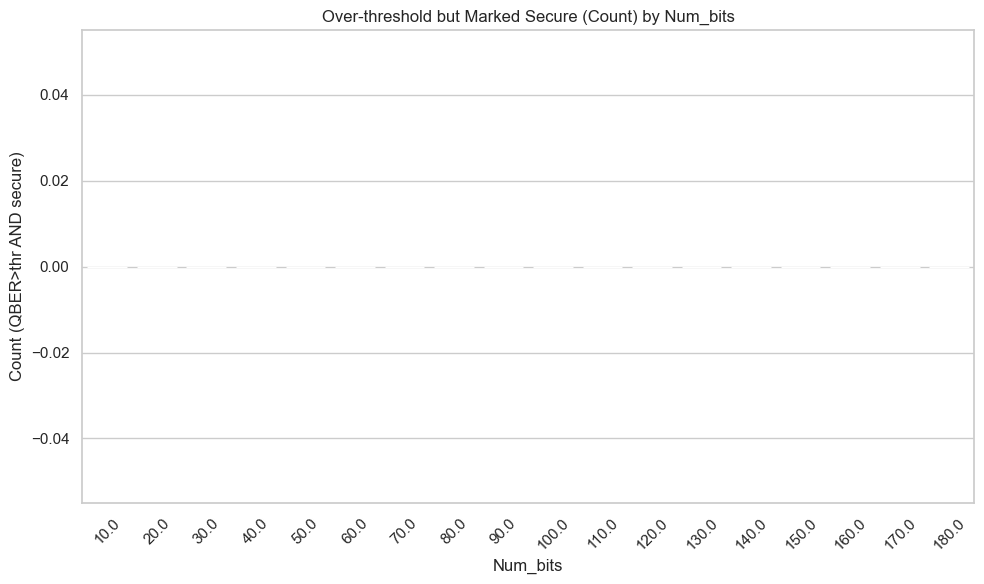

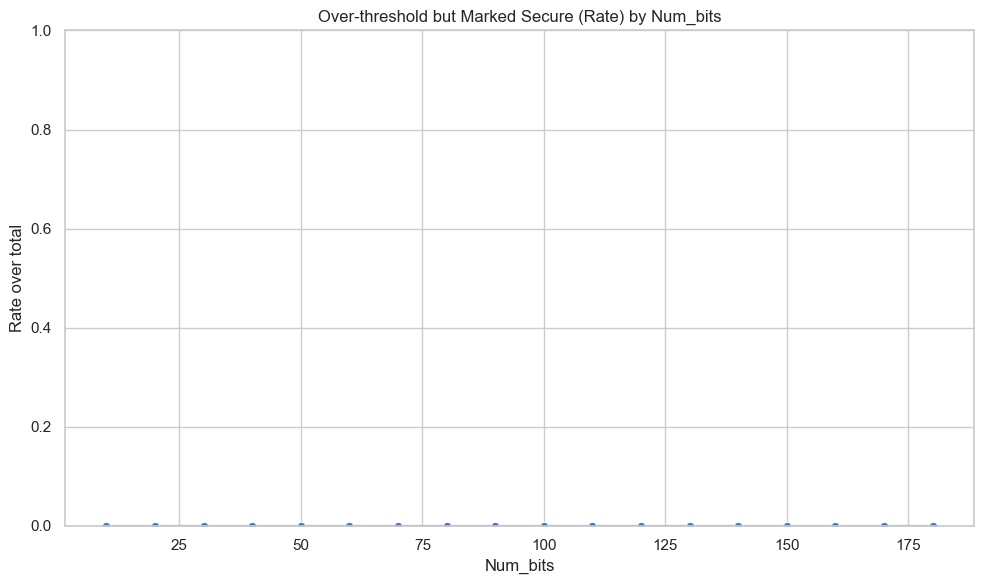

<Figure size 1000x600 with 0 Axes>

In [18]:
# Per-Num_bits breakdown and visualizations
thr_bits = thr_df.copy()

# Ensure Num_bits numeric
thr_bits['Num_bits'] = pd.to_numeric(thr_bits['Num_bits'], errors='coerce') if 'Num_bits' in thr_bits.columns else pd.Series(dtype='float')
thr_bits = thr_bits.dropna(subset=['Num_bits'])

# Precompute conjunctions to avoid index alignment issues
thr_bits['over_and_secure_bool'] = (thr_bits['qber_over'] & thr_bits['is_secure']).astype(int)

if len(thr_bits) > 0:
    grp = thr_bits.groupby('Num_bits', as_index=False)
    bits_df = grp.agg(
        total=('qber_over','size'),
        over=('qber_over','sum'),
        secure=('is_secure','sum'),
        over_and_secure=('over_and_secure_bool','sum')
    )

    # Rates
    bits_df['over_rate'] = bits_df['over'] / bits_df['total']
    bits_df['secure_rate'] = bits_df['secure'] / bits_df['total']
    bits_df['over_and_secure_rate_over_total'] = bits_df['over_and_secure'] / bits_df['total']
    bits_df['over_and_secure_share_of_secure'] = bits_df.apply(lambda r: (r['over_and_secure']/r['secure']) if r['secure']>0 else 0.0, axis=1)

    display(bits_df.sort_values('Num_bits'))

    # Save per-bits table
    bits_path = os.path.join(OUT_DIR, 'qber_threshold_vs_result_by_bits.csv')
    bits_df.sort_values('Num_bits').to_csv(bits_path, index=False)
    print('Saved:', bits_path)

    # Plots: counts and rates of over&secure by Num_bits
    ax = sns.barplot(data=bits_df.sort_values('Num_bits'), x='Num_bits', y='over_and_secure', color='mediumpurple')
    ax.set_ylabel('Count (QBER>thr AND secure)')
    ax.tick_params(axis='x', rotation=45)
    save_show(ax, 'Over-threshold but Marked Secure (Count) by Num_bits', 'qber_over_secure_count_by_bits.png')
    plt.clf()

    ax = sns.lineplot(data=bits_df.sort_values('Num_bits'), x='Num_bits', y='over_and_secure_rate_over_total', marker='o')
    ax.set_ylim(0,1)
    ax.set_ylabel('Rate over total')
    save_show(ax, 'Over-threshold but Marked Secure (Rate) by Num_bits', 'qber_over_secure_rate_by_bits.png')
    plt.clf()
else:
    print('No rows with valid Num_bits for per-bits QBER threshold analysis.')

## ROC Analysis by Num_bits and Interception Density
We compute ROC curves using QBER as the decision score with ground truth `Attack label` (1=attack, 0=no attack). For each `Num_bits`, and for fixed bins of `Interception Density`, we plot FP rate vs detection probability (TP rate). Then we derive an adaptive threshold rule: for a target security level ε (max false-positive rate), choose the lowest threshold achieving FP≤ε while maximizing TP.

C:\Users\alvar\AppData\Local\Temp\ipykernel_19284\722606424.py:37: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for dbin, g in g_nb.groupby('density_bin'):


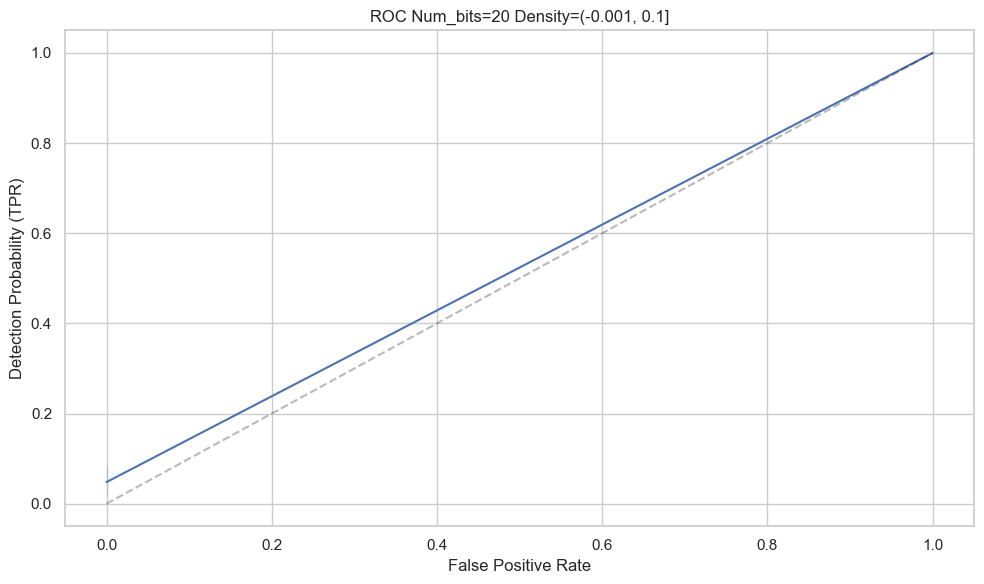

C:\Users\alvar\AppData\Local\Temp\ipykernel_19284\722606424.py:37: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for dbin, g in g_nb.groupby('density_bin'):


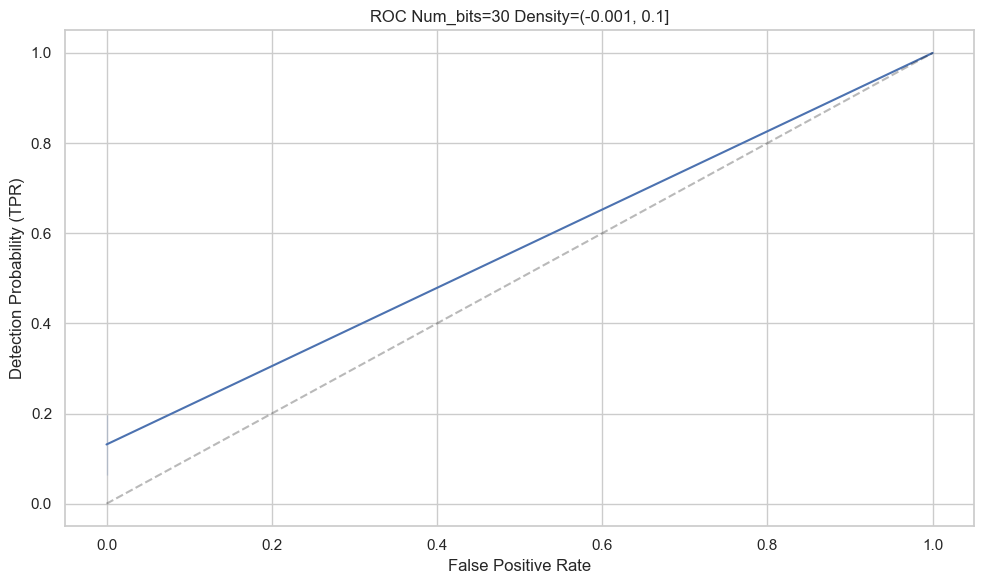

C:\Users\alvar\AppData\Local\Temp\ipykernel_19284\722606424.py:37: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for dbin, g in g_nb.groupby('density_bin'):


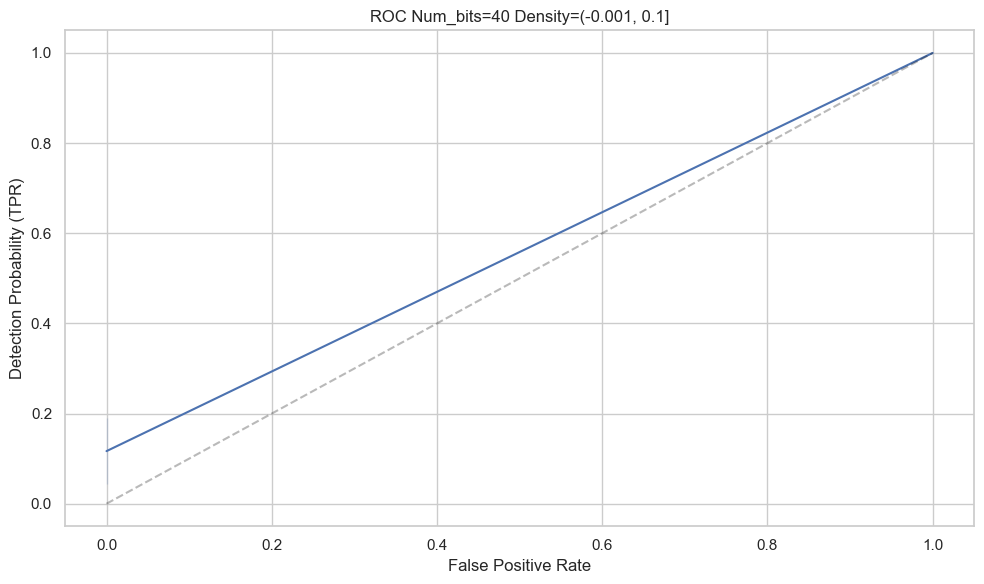

C:\Users\alvar\AppData\Local\Temp\ipykernel_19284\722606424.py:37: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for dbin, g in g_nb.groupby('density_bin'):


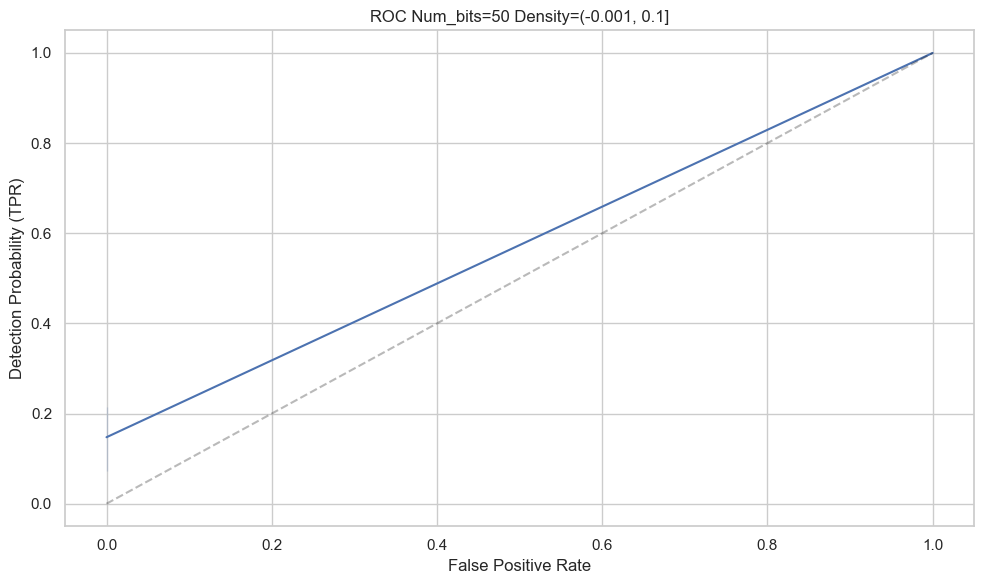

C:\Users\alvar\AppData\Local\Temp\ipykernel_19284\722606424.py:37: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for dbin, g in g_nb.groupby('density_bin'):


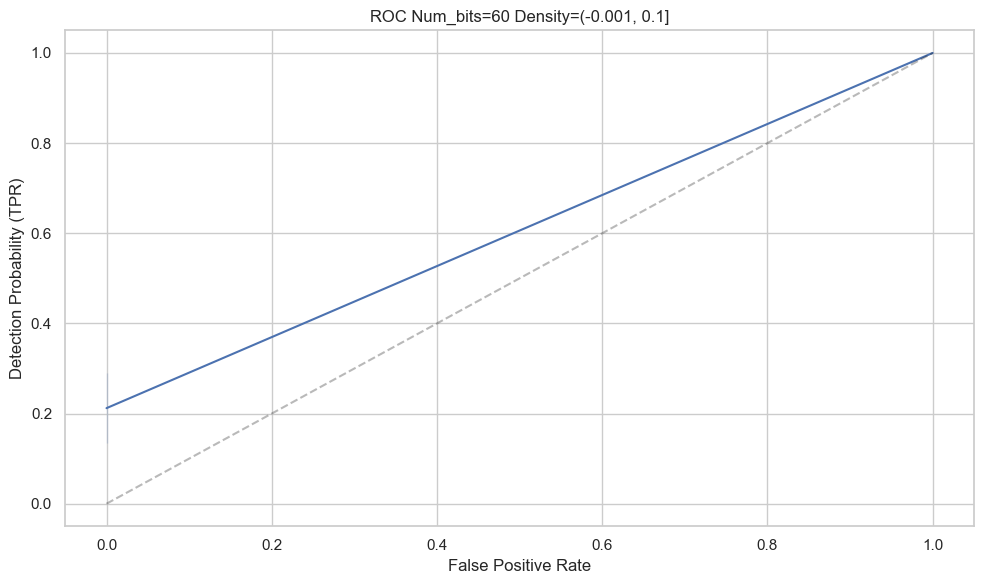

C:\Users\alvar\AppData\Local\Temp\ipykernel_19284\722606424.py:37: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for dbin, g in g_nb.groupby('density_bin'):


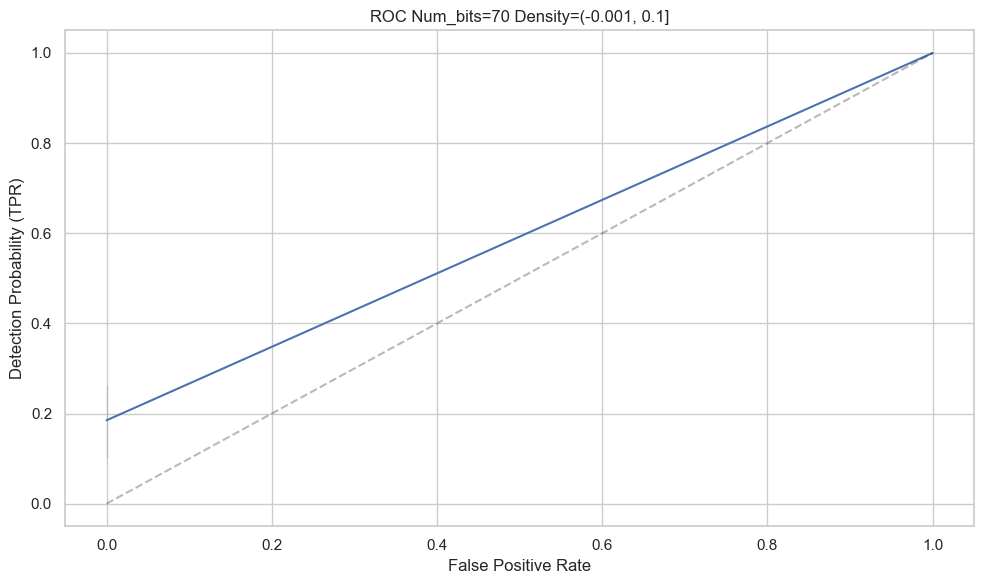

C:\Users\alvar\AppData\Local\Temp\ipykernel_19284\722606424.py:37: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for dbin, g in g_nb.groupby('density_bin'):


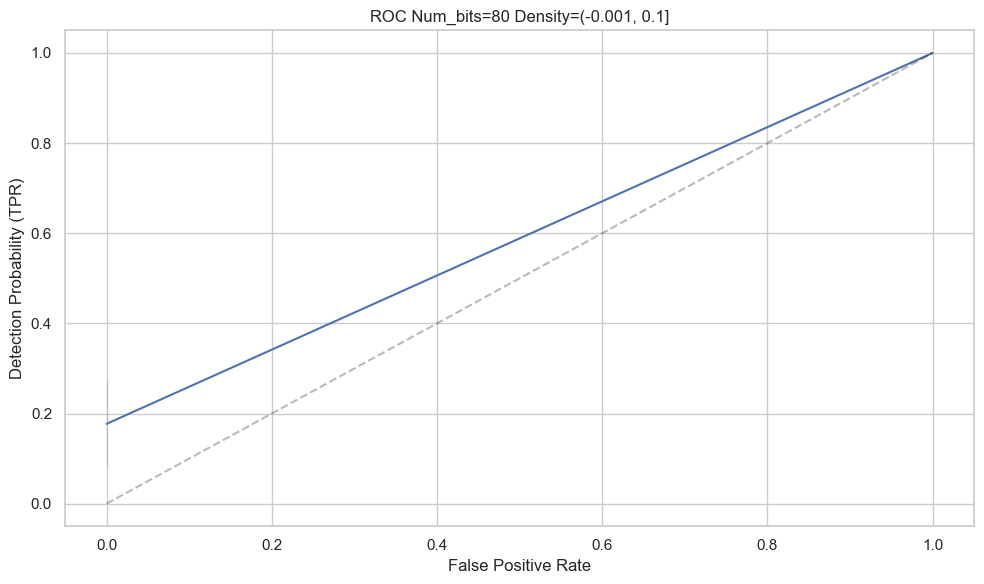

C:\Users\alvar\AppData\Local\Temp\ipykernel_19284\722606424.py:37: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for dbin, g in g_nb.groupby('density_bin'):


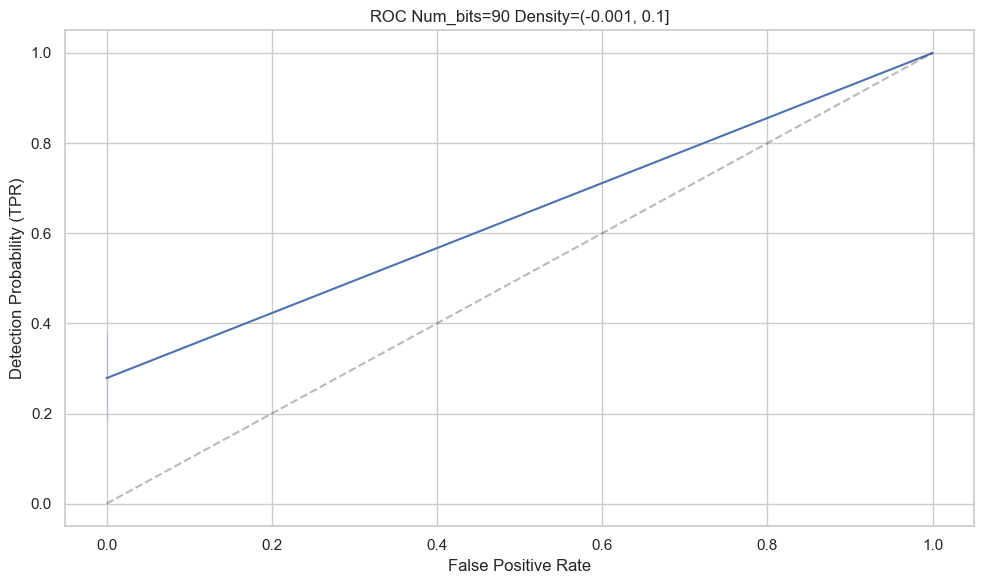

C:\Users\alvar\AppData\Local\Temp\ipykernel_19284\722606424.py:37: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for dbin, g in g_nb.groupby('density_bin'):


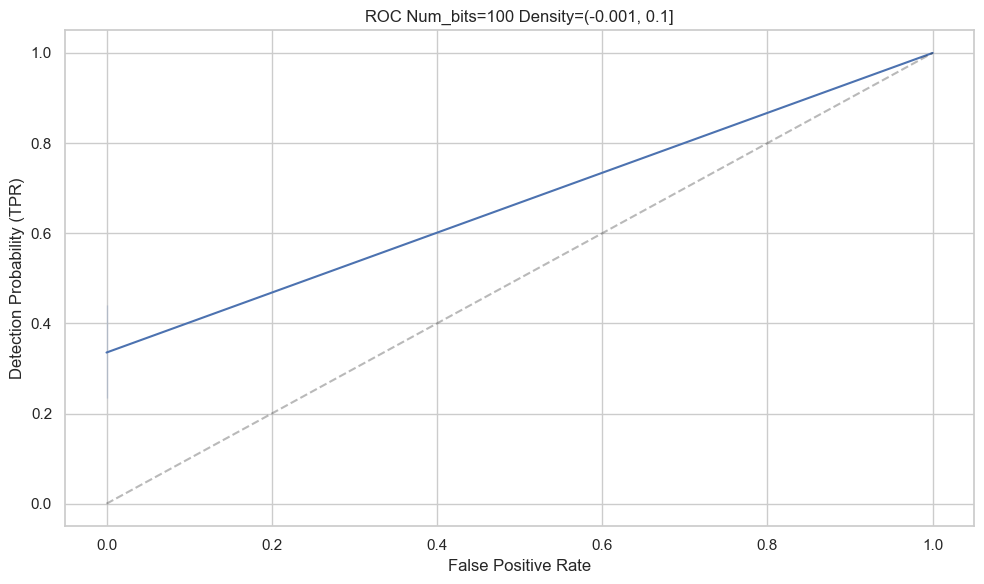

C:\Users\alvar\AppData\Local\Temp\ipykernel_19284\722606424.py:37: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for dbin, g in g_nb.groupby('density_bin'):


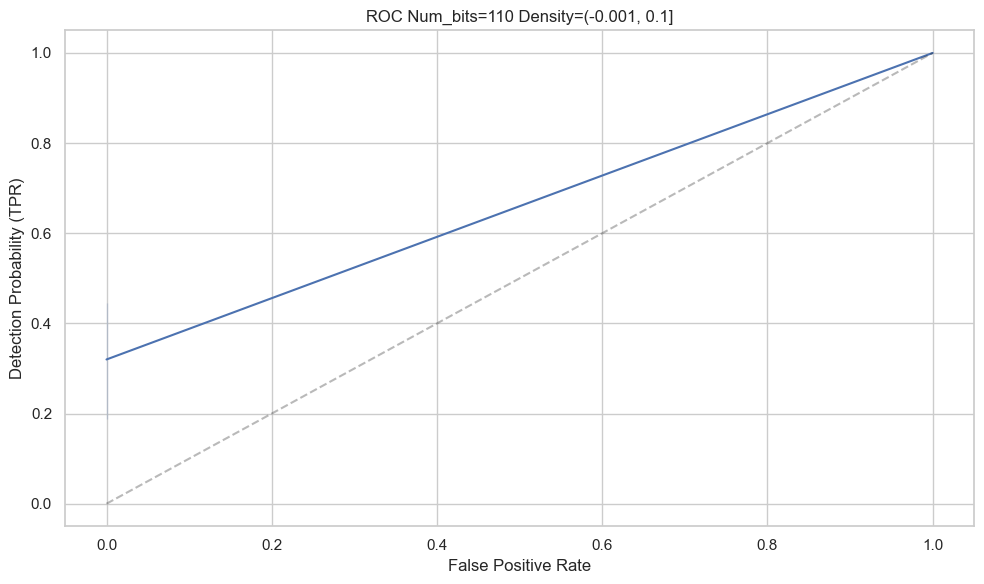

C:\Users\alvar\AppData\Local\Temp\ipykernel_19284\722606424.py:37: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for dbin, g in g_nb.groupby('density_bin'):


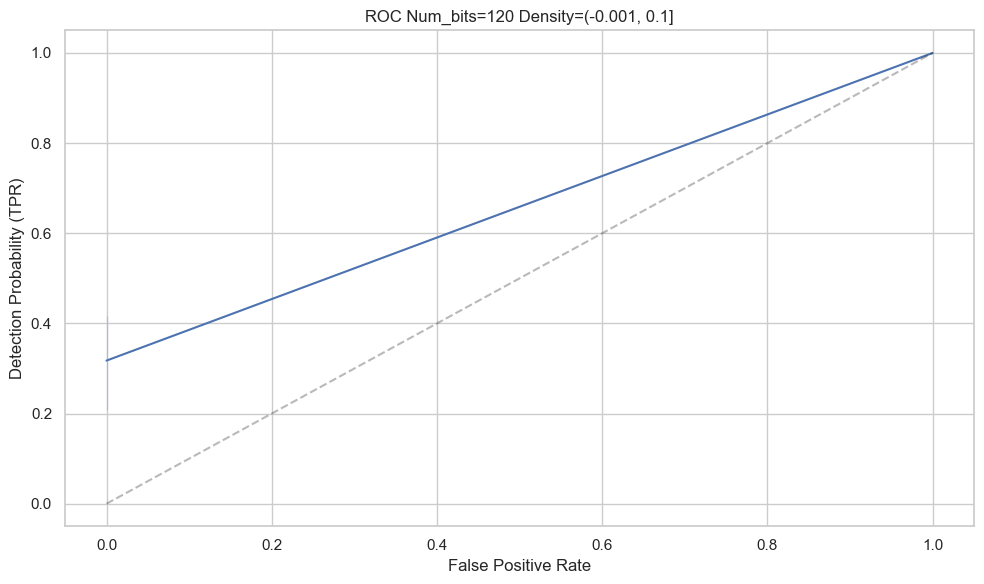

C:\Users\alvar\AppData\Local\Temp\ipykernel_19284\722606424.py:37: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for dbin, g in g_nb.groupby('density_bin'):


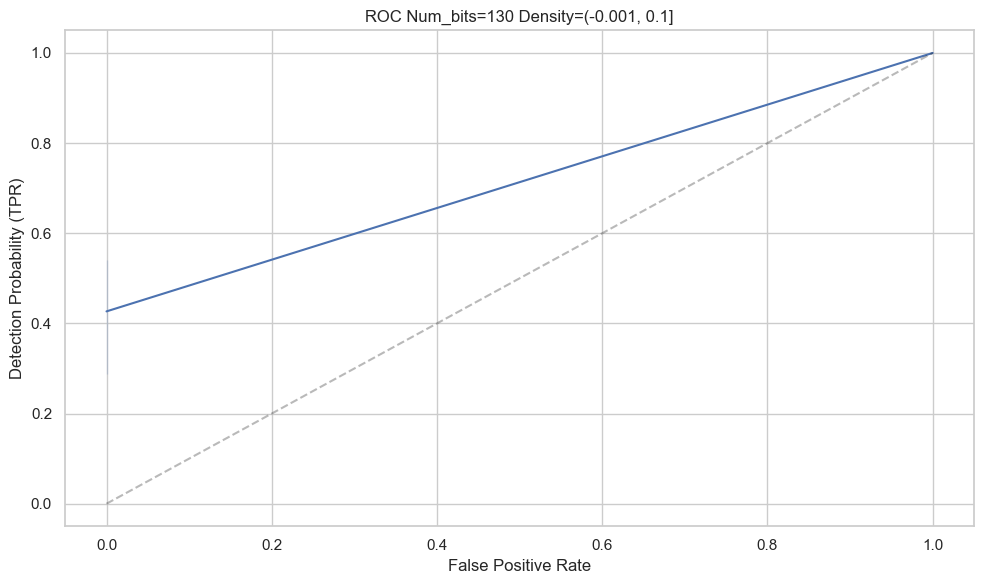

C:\Users\alvar\AppData\Local\Temp\ipykernel_19284\722606424.py:37: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for dbin, g in g_nb.groupby('density_bin'):


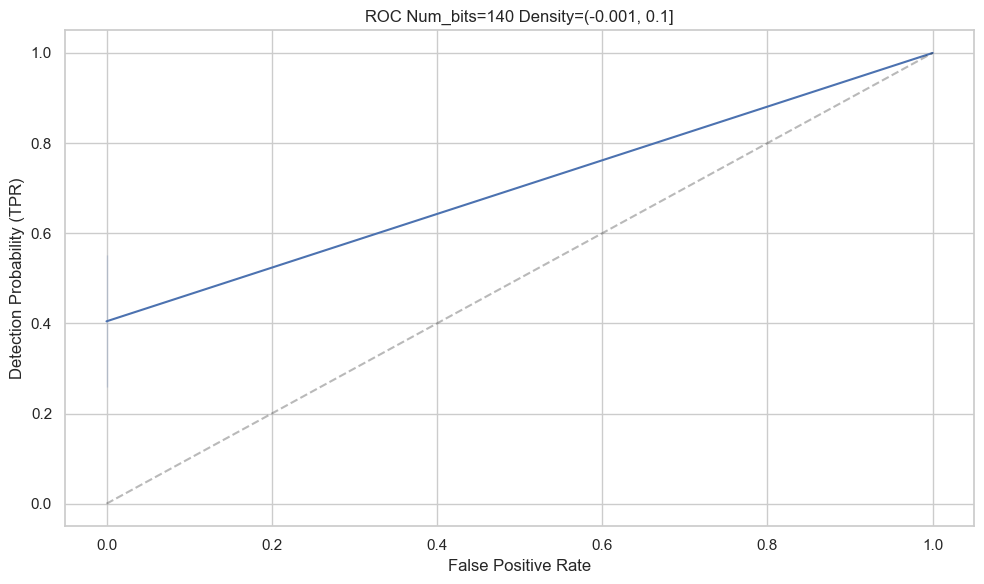

C:\Users\alvar\AppData\Local\Temp\ipykernel_19284\722606424.py:37: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for dbin, g in g_nb.groupby('density_bin'):


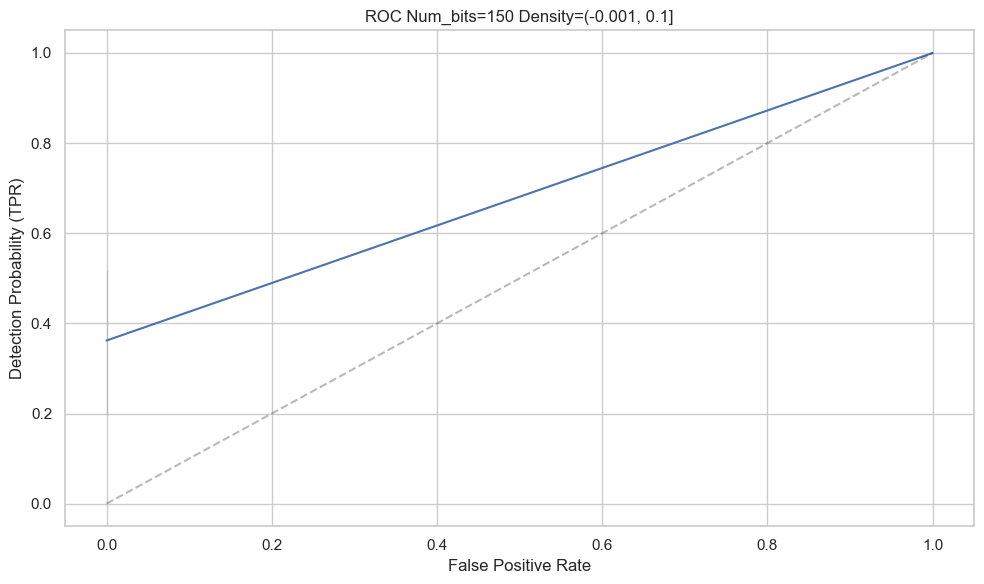

C:\Users\alvar\AppData\Local\Temp\ipykernel_19284\722606424.py:37: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for dbin, g in g_nb.groupby('density_bin'):


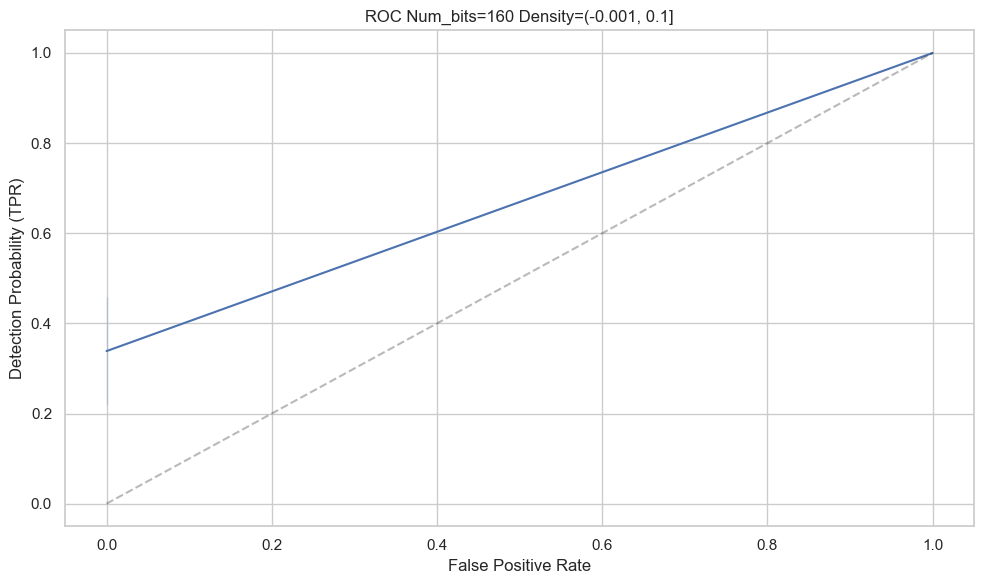

C:\Users\alvar\AppData\Local\Temp\ipykernel_19284\722606424.py:37: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for dbin, g in g_nb.groupby('density_bin'):


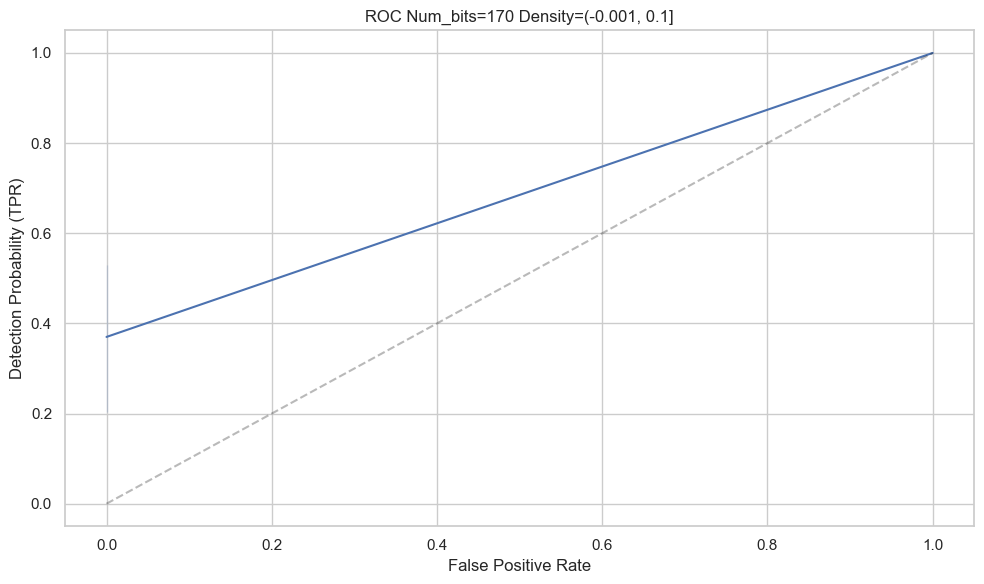

C:\Users\alvar\AppData\Local\Temp\ipykernel_19284\722606424.py:37: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for dbin, g in g_nb.groupby('density_bin'):


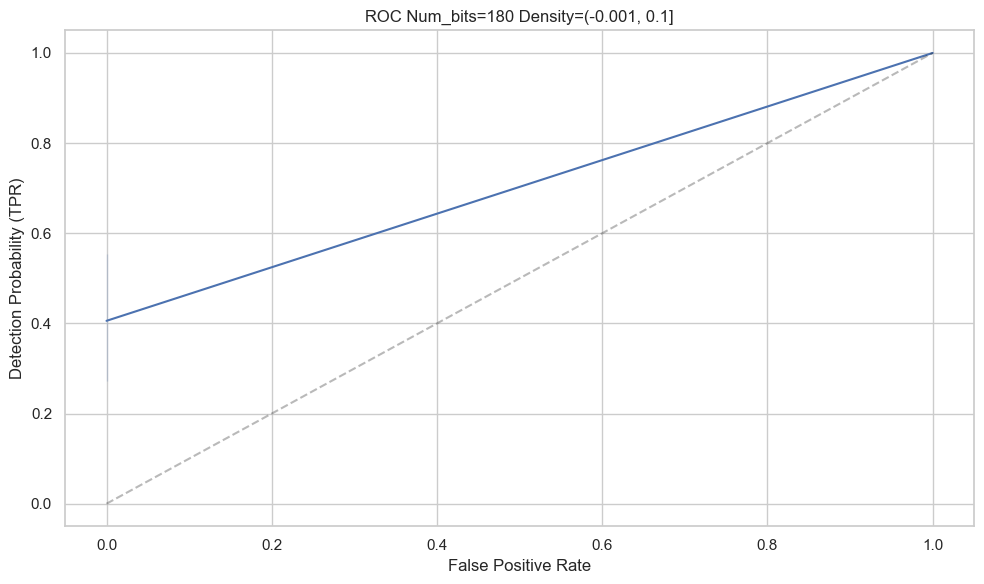

,Num_bits,density_bin,epsilon,threshold,fpr,tpr
0,20.0,"(-0.001, 0.1]",0.05,0.083333,0.0,0.10
1,30.0,"(-0.001, 0.1]",0.05,0.043478,0.0,0.26
2,40.0,"(-0.001, 0.1]",0.05,0.040000,0.0,0.28
3,50.0,"(-0.001, 0.1]",0.05,0.031250,0.0,0.30
4,60.0,"(-0.001, 0.1]",0.05,0.025641,0.0,0.44
5,70.0,"(-0.001, 0.1]",0.05,0.025000,0.0,0.36
6,80.0,"(-0.001, 0.1]",0.05,0.020833,0.0,0.38
7,90.0,"(-0.001, 0.1]",0.05,0.019231,0.0,0.56
8,100.0,"(-0.001, 0.1]",0.05,0.016667,0.0,0.64
9,110.0,"(-0.001, 0.1]",0.05,0.016393,0.0,0.58


Saved adaptive thresholds: ./data\ml_outputs\adaptive_thresholds_by_bits_density.csv


<Figure size 1000x600 with 0 Axes>

In [20]:
# Compute ROC per Num_bits under fixed Interception Density
from sklearn.metrics import roc_curve

# Configuration
THRESHOLD_GRID = None  # use all unique QBERs via roc_curve
EPSILON = 0.05  # target max false-positive rate
DENSITY_BINS = 4  # number of quantile bins for Interception Density

# Select QBER column
qber_candidates = ['Raw_sifted_QBER', 'Shared BER', 'Full key BER']
avail_qber = [c for c in qber_candidates if c in df.columns]
if not avail_qber:
    raise KeyError("No QBER-like column found for ROC analysis.")
QBER_COL = avail_qber[0]

# Prepare data
roc_df = df.copy()
needed_cols = ['Attack label', QBER_COL, 'Num_bits', 'Interception Density']
for c in needed_cols:
    if c not in roc_df.columns:
        raise KeyError(f"Required column '{c}' not found for ROC analysis.")
roc_df['Attack label'] = pd.to_numeric(roc_df['Attack label'], errors='coerce')
roc_df[QBER_COL] = pd.to_numeric(roc_df[QBER_COL], errors='coerce')
roc_df['Num_bits'] = pd.to_numeric(roc_df['Num_bits'], errors='coerce')
roc_df['Interception Density'] = pd.to_numeric(roc_df['Interception Density'], errors='coerce')
roc_df = roc_df.dropna(subset=['Attack label', QBER_COL, 'Num_bits', 'Interception Density'])
roc_df['Attack label'] = roc_df['Attack label'].astype(int)

# Bin Interception Density by quantiles to form fixed-density slices
roc_df['density_bin'] = pd.qcut(roc_df['Interception Density'], q=DENSITY_BINS, duplicates='drop')

adaptive_rules = []
plots_roc = []

# Iterate per Num_bits and density_bin
for nb, g_nb in roc_df.groupby('Num_bits'):
    for dbin, g in g_nb.groupby('density_bin'):
        if g['Attack label'].nunique() < 2:
            # Need both classes to build ROC
            continue
        y_true = g['Attack label'].values
        y_score = g[QBER_COL].values
        # Using QBER directly: higher QBER -> more likely attack
        fpr, tpr, thresholds = roc_curve(y_true, y_score)
        roc_tbl = pd.DataFrame({'Num_bits': nb, 'density_bin': str(dbin), 'threshold': thresholds, 'fpr': fpr, 'tpr': tpr})
        # Save best threshold under FP constraint
        candidates = roc_tbl[roc_tbl['fpr'] <= EPSILON]
        if len(candidates) == 0:
            # fallback: pick minimal fpr
            cand = roc_tbl.loc[roc_tbl['fpr'].idxmin()]
        else:
            # pick candidate with max tpr, tie-break by lowest threshold
            cand = candidates.sort_values(['tpr','threshold'], ascending=[False, True]).iloc[0]
        adaptive_rules.append({
            'Num_bits': nb,
            'density_bin': str(dbin),
            'epsilon': EPSILON,
            'threshold': float(cand['threshold']),
            'fpr': float(cand['fpr']),
            'tpr': float(cand['tpr'])
        })
        # Plot ROC curve
        ax = sns.lineplot(x=fpr, y=tpr)
        ax.set_title(f'ROC (Num_bits={int(nb)}, Density={dbin})')
        ax.set_xlabel('False Positive Rate')
        ax.set_ylabel('Detection Probability (TPR)')
        plt.plot([0,1],[0,1],'k--',alpha=0.3)
        save_show(ax, f'ROC Num_bits={int(nb)} Density={dbin}', f"roc_nb{int(nb)}_dens_{str(dbin).replace(' ','_').replace(',','_')}.png")
        plt.clf()

# Compile adaptive rule table
adaptive_df = pd.DataFrame(adaptive_rules)
if len(adaptive_df) > 0:
    display(adaptive_df.sort_values(['Num_bits','density_bin']))
    rule_path = os.path.join(OUT_DIR, 'adaptive_thresholds_by_bits_density.csv')
    adaptive_df.sort_values(['Num_bits','density_bin']).to_csv(rule_path, index=False)
    print('Saved adaptive thresholds:', rule_path)
else:
    print('Insufficient data to compute ROC and adaptive thresholds.')

## Adaptive Threshold Rule (Function of Num_bits and ε)
Using the `adaptive_thresholds_by_bits_density` table, we fit a simple, interpretable rule to produce a QBER threshold given `Num_bits` and target false-positive level ε. We interpolate over `Num_bits` within each density bin and scale thresholds approximately with ε when needed.

,Range,Samples,Baseline_Acc,RF_Acc,SVM_Acc
0,20-100,5625,0.884800,0.895111,0.888889
1,20-90,5000,0.876200,0.875000,0.876000
2,20-80,4375,0.865371,0.882286,0.875429
3,20-70,3750,0.853867,0.864000,0.858667
4,20-60,3125,0.839680,0.867200,0.862400
5,20-50,2500,0.820400,0.864000,0.848000
6,20-40,1875,0.797333,0.824000,0.816000
7,20-30,1250,0.759200,0.780000,0.764000
8,20-25,625,0.712000,0.712000,0.712000


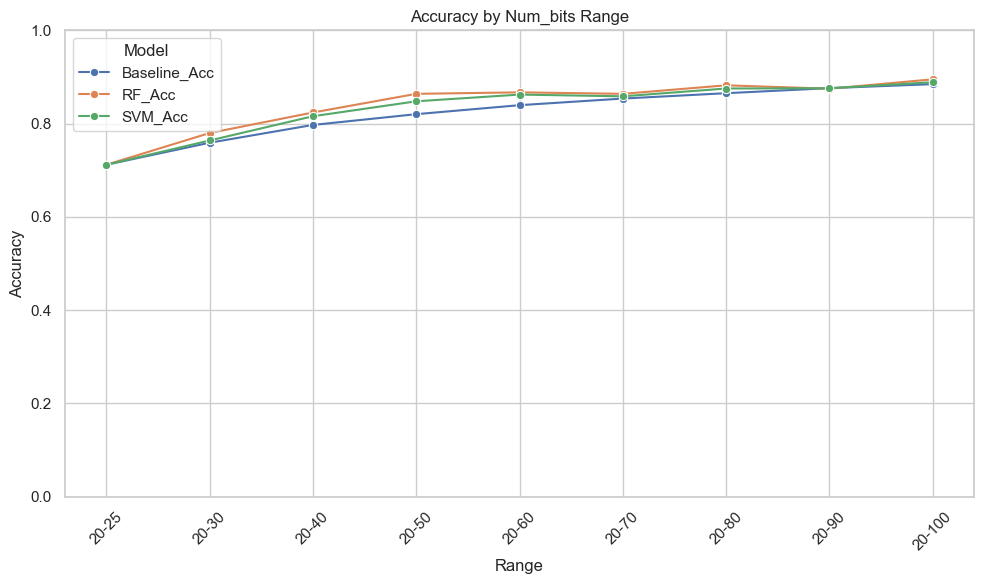

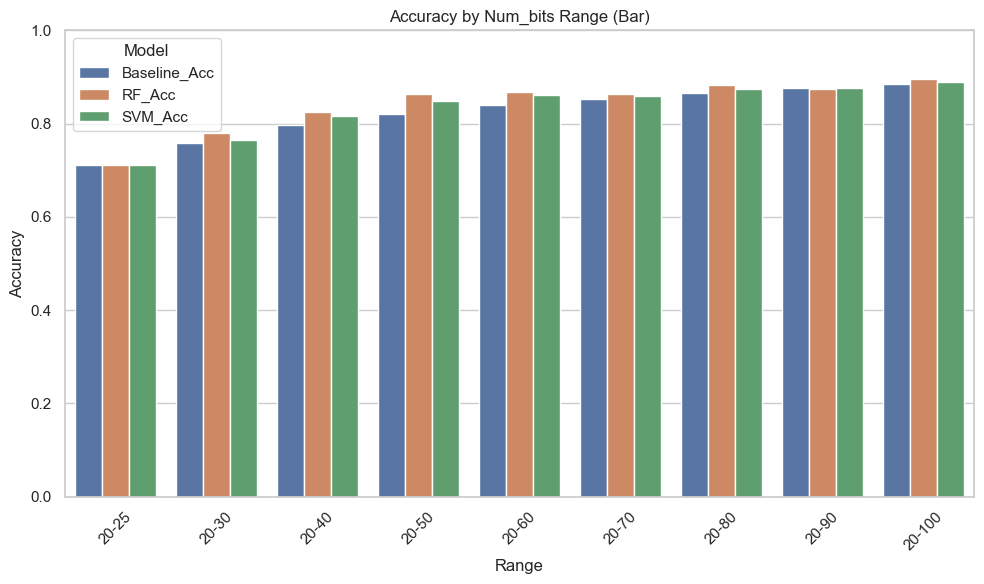

<Figure size 1000x600 with 0 Axes>

In [22]:
# Accuracy comparison visualization from training script
import os
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Paths should align with the training script output
ROOT = './data'
OUT_DIR = os.path.join(ROOT, 'ml_outputs')
CSV_PATH = os.path.join(OUT_DIR, 'accuracy_comparison_by_num_bits.csv')

if os.path.exists(CSV_PATH):
    comp = pd.read_csv(CSV_PATH)
    display(comp)

    # Melt for plotting multiple models on the same figure
    plot_df = comp.melt(id_vars=['Range','Samples'],
                        value_vars=['Baseline_Acc','RF_Acc','SVM_Acc'],
                        var_name='Model', value_name='Accuracy')

    # Ensure range is treated in logical order by high bound
    # Extract upper bound for sorting
    try:
        plot_df['high'] = plot_df['Range'].str.split('-').str[1].astype(int)
        plot_df = plot_df.sort_values('high')
    except Exception:
        pass

    sns.set(style='whitegrid')

    # Line plot: Accuracy vs Num_bits upper bound
    ax = sns.lineplot(data=plot_df, x='Range', y='Accuracy', hue='Model', marker='o')
    ax.tick_params(axis='x', rotation=45)
    ax.set_ylim(0, 1)
    ax.set_title('Accuracy by Num_bits Range')
    plt.tight_layout()
    out_path = os.path.join(OUT_DIR, 'accuracy_by_range_line.png')
    plt.savefig(out_path)
    plt.show()

    plt.clf()

    # Bar plot: Accuracy by range
    ax = sns.barplot(data=plot_df, x='Range', y='Accuracy', hue='Model')
    ax.tick_params(axis='x', rotation=45)
    ax.set_ylim(0, 1)
    ax.set_title('Accuracy by Num_bits Range (Bar)')
    plt.tight_layout()
    out_path = os.path.join(OUT_DIR, 'accuracy_by_range_bar.png')
    plt.savefig(out_path)
    plt.show()

    plt.clf()
else:
    print('Comparison CSV not found:', CSV_PATH)


,Range,Samples,Baseline_Acc,RF_Acc,SVM_Acc,RF_Impr,SVM_Impr
0,20-180,10565,0.926171,0.931377,0.926645,0.005206,0.000473
1,20-100,5625,0.884800,0.895111,0.888889,0.010311,0.004089
2,20-60,3125,0.839680,0.867200,0.862400,0.027520,0.022720
3,20-50,2500,0.820400,0.864000,0.848000,0.043600,0.027600
4,20-40,1875,0.797333,0.824000,0.816000,0.026667,0.018667
5,20-30,1250,0.759200,0.780000,0.764000,0.020800,0.004800


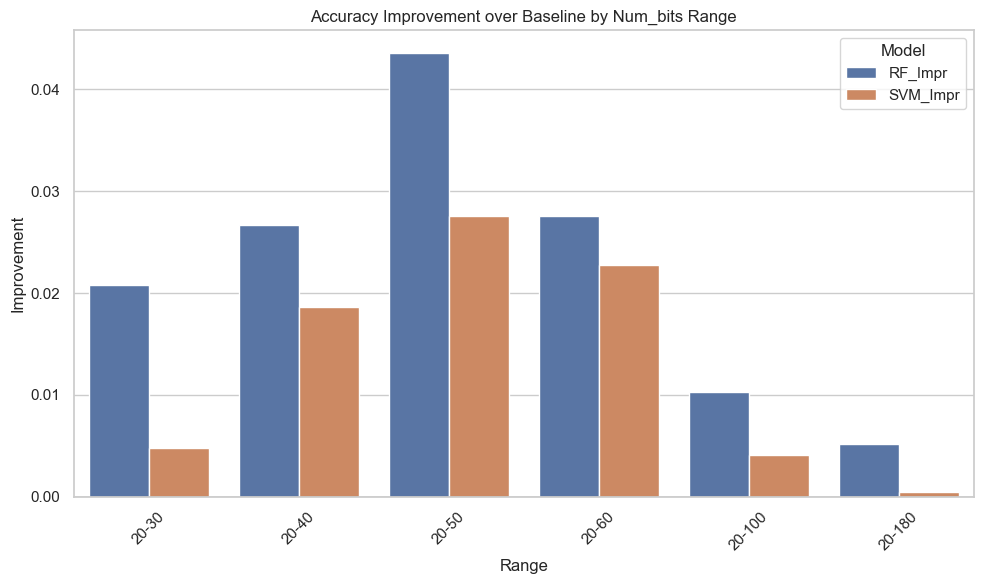

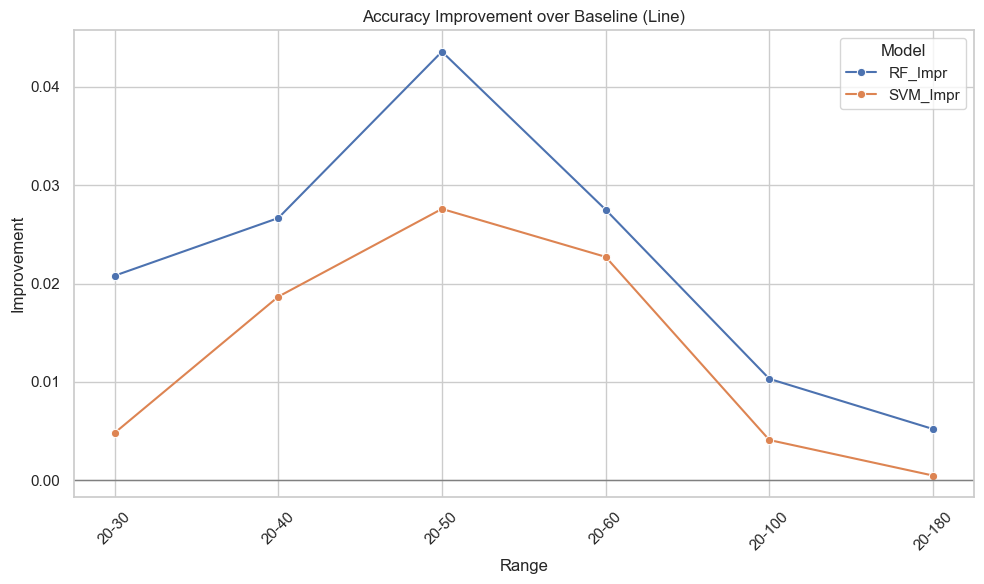

<Figure size 1000x600 with 0 Axes>

In [51]:
# Accuracy improvement over baseline visualization
import os
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

ROOT = './data'
OUT_DIR = os.path.join(ROOT, 'ml_outputs')
CSV_PATH = os.path.join(OUT_DIR, 'accuracy_comparison_by_num_bits.csv')

if os.path.exists(CSV_PATH):
    comp = pd.read_csv(CSV_PATH)
    # Compute improvements (model accuracy minus baseline)
    comp['RF_Impr'] = comp['RF_Acc'] - comp['Baseline_Acc']
    comp['SVM_Impr'] = comp['SVM_Acc'] - comp['Baseline_Acc']

    display(comp[['Range','Samples','Baseline_Acc','RF_Acc','SVM_Acc','RF_Impr','SVM_Impr']])

    # Melt for unified plotting
    impr_df = comp.melt(id_vars=['Range','Samples'],
                        value_vars=['RF_Impr','SVM_Impr'],
                        var_name='Model', value_name='Improvement')

    # Sort by upper bound of range for readability
    try:
        impr_df['high'] = impr_df['Range'].str.split('-').str[1].astype(int)
        impr_df = impr_df.sort_values('high')
    except Exception:
        pass

    sns.set(style='whitegrid')

    # Bar plot of improvements by range
    ax = sns.barplot(data=impr_df, x='Range', y='Improvement', hue='Model')
    ax.tick_params(axis='x', rotation=45)
    ax.set_title('Accuracy Improvement over Baseline by Num_bits Range')
    ax.axhline(0, color='gray', linewidth=1)
    plt.tight_layout()
    out_path = os.path.join(OUT_DIR, 'accuracy_improvement_by_range_bar.png')
    plt.savefig(out_path)
    plt.show()

    plt.clf()

    # Line plot of improvements
    ax = sns.lineplot(data=impr_df, x='Range', y='Improvement', hue='Model', marker='o')
    ax.tick_params(axis='x', rotation=45)
    ax.set_title('Accuracy Improvement over Baseline (Line)')
    ax.axhline(0, color='gray', linewidth=1)
    plt.tight_layout()
    out_path = os.path.join(OUT_DIR, 'accuracy_improvement_by_range_line.png')
    plt.savefig(out_path)
    plt.show()

    plt.clf()
else:
    print('Comparison CSV not found:', CSV_PATH)


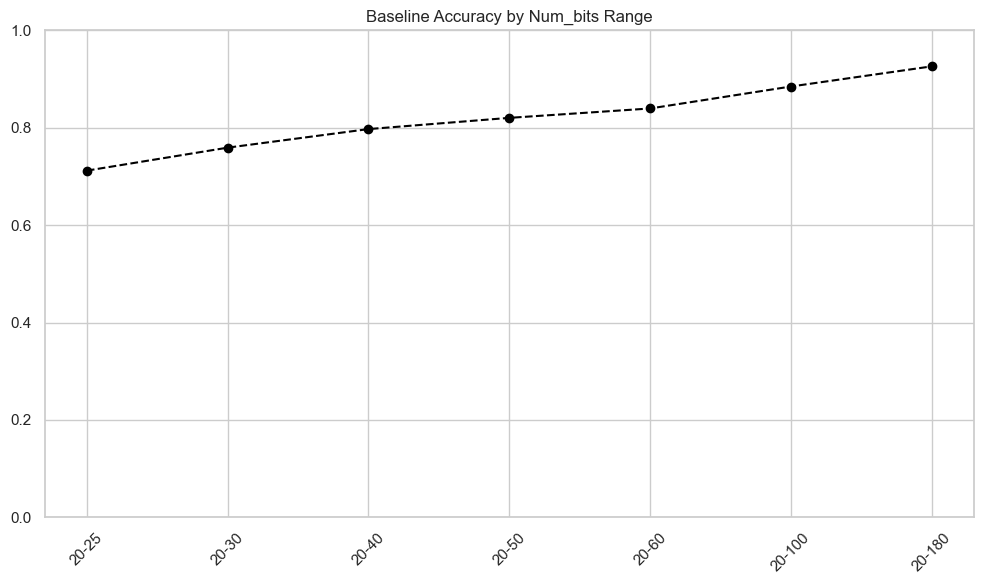

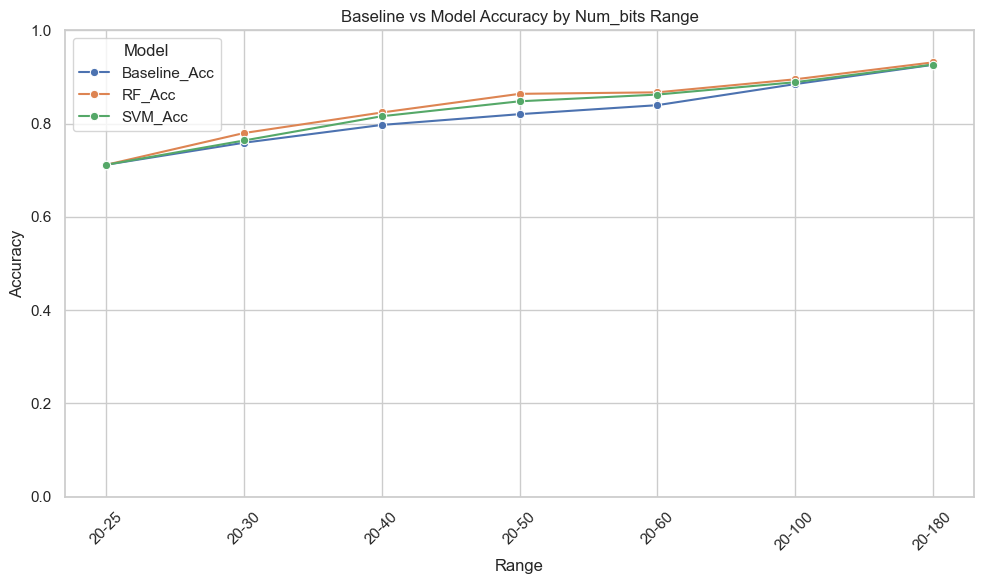

<Figure size 1000x600 with 0 Axes>

In [39]:
# Overlay baseline accuracy on improvement charts
import os
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

ROOT = './data'
OUT_DIR = os.path.join(ROOT, 'ml_outputs')
CSV_PATH = os.path.join(OUT_DIR, 'accuracy_comparison_by_num_bits.csv')

if os.path.exists(CSV_PATH):
    comp = pd.read_csv(CSV_PATH)

    # Sort ranges by upper bound for consistent plotting
    try:
        comp['high'] = comp['Range'].str.split('-').str[1].astype(int)
        comp = comp.sort_values('high')
    except Exception:
        pass

    sns.set(style='whitegrid')

    # Baseline line to accompany improvement plots
    # This does not change the improvement values but adds context
    fig, ax = plt.subplots()
    ax.plot(comp['Range'], comp['Baseline_Acc'], label='Baseline_Acc', color='black', linestyle='--', marker='o')
    ax.set_ylim(0, 1)
    ax.tick_params(axis='x', rotation=45)
    ax.set_title('Baseline Accuracy by Num_bits Range')
    plt.tight_layout()
    out_path = os.path.join(OUT_DIR, 'baseline_accuracy_by_range_line.png')
    plt.savefig(out_path)
    plt.show()
    plt.clf()

    # Combined accuracy plot including baseline and models for convenience
    plot_df = comp.melt(id_vars=['Range','Samples'],
                        value_vars=['Baseline_Acc','RF_Acc','SVM_Acc'],
                        var_name='Model', value_name='Accuracy')

    ax = sns.lineplot(data=plot_df, x='Range', y='Accuracy', hue='Model', marker='o')
    ax.tick_params(axis='x', rotation=45)
    ax.set_ylim(0, 1)
    ax.set_title('Baseline vs Model Accuracy by Num_bits Range')
    plt.tight_layout()
    out_path = os.path.join(OUT_DIR, 'baseline_vs_models_accuracy_by_range_line.png')
    plt.savefig(out_path)
    plt.show()
    plt.clf()
else:
    print('Comparison CSV not found:', CSV_PATH)


,Range,Samples,Baseline_Recall,RF_Recall,SVM_Recall,RF_Recall_Impr,SVM_Recall_Impr
0,20-180,10565,0.907583,0.915877,0.908175,0.008294,0.000592
1,20-100,5625,0.856000,0.873333,0.861111,0.017333,0.005111
2,20-60,3125,0.799600,0.850000,0.828000,0.050400,0.028400
3,20-50,2500,0.775500,0.852500,0.810000,0.077000,0.034500
4,20-40,1875,0.746667,0.816667,0.770000,0.070000,0.023333
5,20-30,1250,0.699000,0.780000,0.705000,0.081000,0.006000


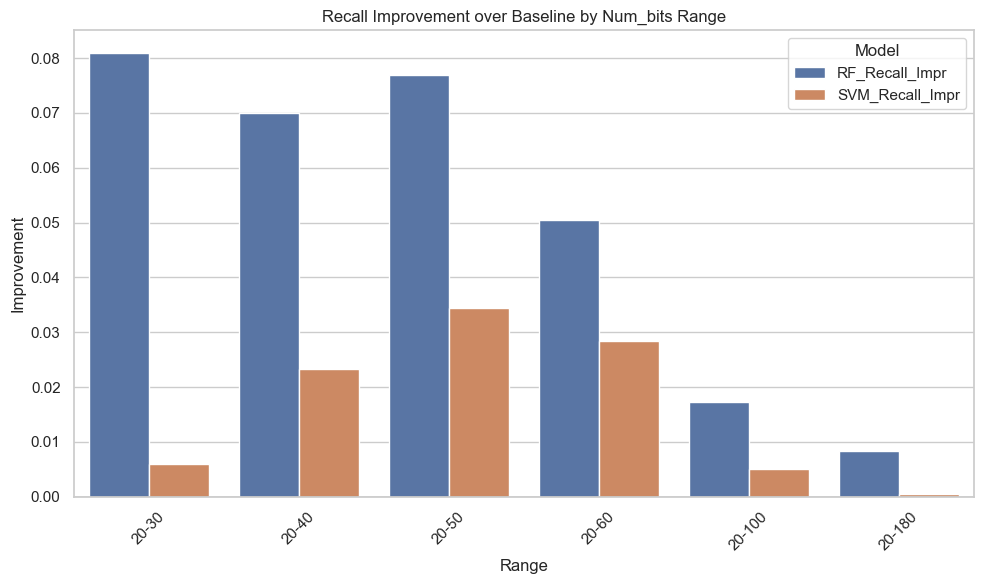

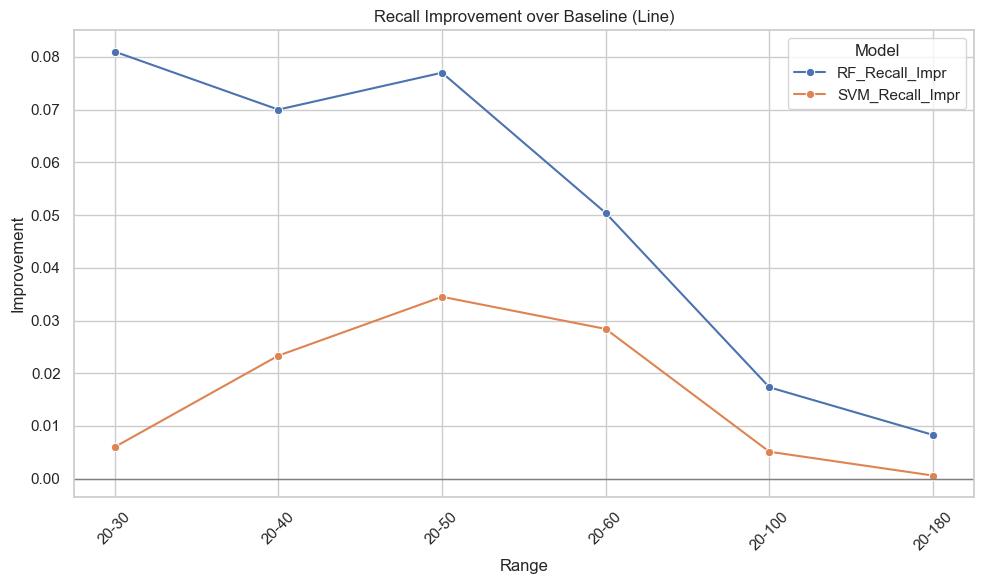

<Figure size 1000x600 with 0 Axes>

In [50]:
# Recall improvement over baseline visualization
ROOT = './data'
OUT_DIR = os.path.join(ROOT, 'ml_outputs')
CSV_PATH = os.path.join(OUT_DIR, 'accuracy_comparison_by_num_bits.csv')

if os.path.exists(CSV_PATH):
    comp = pd.read_csv(CSV_PATH)
    
    # Check if recall columns exist
    if 'RF_Recall' in comp.columns and 'SVM_Recall' in comp.columns and 'Baseline_Recall' in comp.columns:
        # Compute improvements (model recall minus baseline)
        comp['RF_Recall_Impr'] = comp['RF_Recall'] - comp['Baseline_Recall']
        comp['SVM_Recall_Impr'] = comp['SVM_Recall'] - comp['Baseline_Recall']

        display(comp[['Range','Samples','Baseline_Recall','RF_Recall','SVM_Recall','RF_Recall_Impr','SVM_Recall_Impr']])

        # Melt for unified plotting
        impr_df = comp.melt(id_vars=['Range','Samples'],
                            value_vars=['RF_Recall_Impr','SVM_Recall_Impr'],
                            var_name='Model', value_name='Improvement')

        # Sort by upper bound of range for readability
        try:
            impr_df['high'] = impr_df['Range'].str.split('-').str[1].astype(int)
            impr_df = impr_df.sort_values('high')
        except Exception:
            pass

        sns.set(style='whitegrid')

        # Bar plot of improvements by range
        ax = sns.barplot(data=impr_df, x='Range', y='Improvement', hue='Model')
        ax.tick_params(axis='x', rotation=45)
        ax.set_title('Recall Improvement over Baseline by Num_bits Range')
        ax.axhline(0, color='gray', linewidth=1)
        plt.tight_layout()
        out_path = os.path.join(OUT_DIR, 'recall_improvement_by_range_bar.png')
        plt.savefig(out_path)
        plt.show()

        plt.clf()

        # Line plot of improvements
        ax = sns.lineplot(data=impr_df, x='Range', y='Improvement', hue='Model', marker='o')
        ax.tick_params(axis='x', rotation=45)
        ax.set_title('Recall Improvement over Baseline (Line)')
        ax.axhline(0, color='gray', linewidth=1)
        plt.tight_layout()
        out_path = os.path.join(OUT_DIR, 'recall_improvement_by_range_line.png')
        plt.savefig(out_path)
        plt.show()

        plt.clf()
    else:
        print('Recall columns not found in the comparison CSV. Available columns:', comp.columns.tolist())
else:
    print('Comparison CSV not found:', CSV_PATH)


,Range,Samples,Baseline_Precision,RF_Precision,SVM_Precision,RF_Precision_Impr,SVM_Precision_Impr
6,20-25,625,1.0,0.932432,1.0,-0.067568,0.0
5,20-30,1250,1.0,0.934132,1.0,-0.065868,0.0
4,20-40,1875,1.0,0.957031,1.0,-0.042969,0.0
3,20-50,2500,1.0,0.974286,1.0,-0.025714,0.0
2,20-60,3125,1.0,0.981524,1.0,-0.018476,0.0
1,20-100,5625,1.0,0.994937,1.0,-0.005063,0.0
0,20-180,10565,1.0,0.998063,1.0,-0.001937,0.0


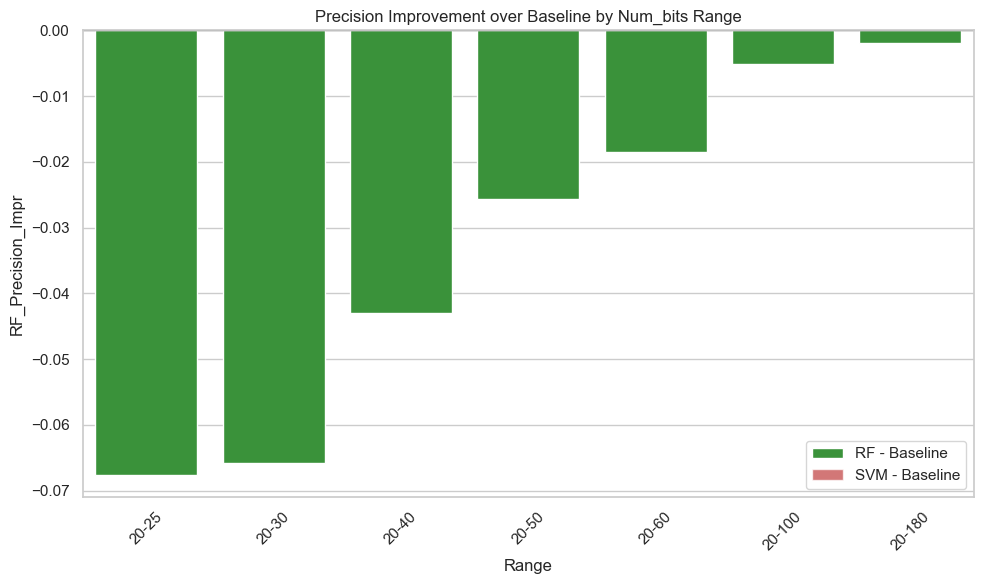

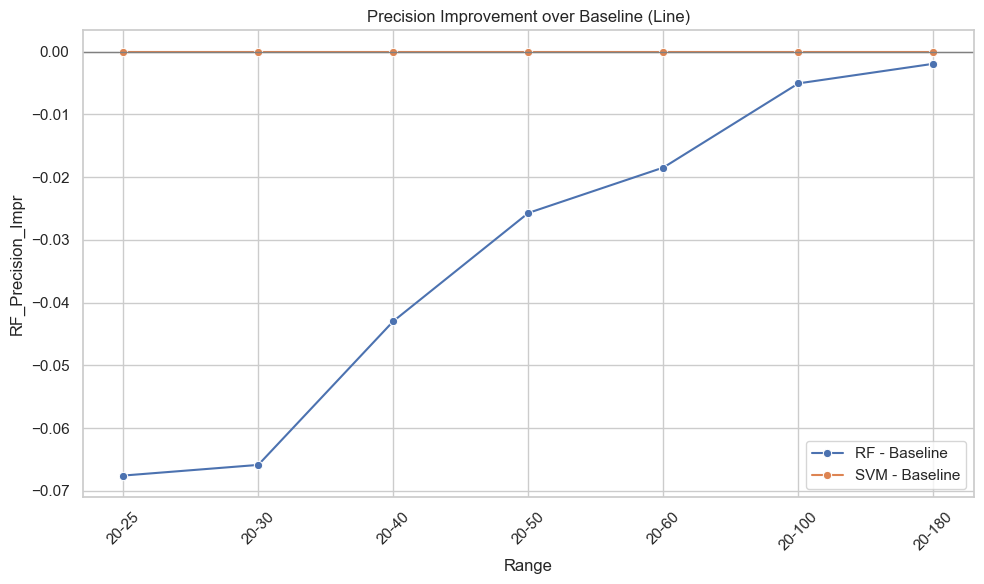

<Figure size 1000x600 with 0 Axes>

In [ ]:
# Precision improvements over baseline by range
import os
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

ROOT = './data'
OUT_DIR = os.path.join(ROOT, 'ml_outputs')
CSV_PATH = os.path.join(OUT_DIR, 'accuracy_comparison_by_num_bits.csv')

comp = pd.read_csv(CSV_PATH)
# Sort by upper bound of range for readability
try:
    comp['high'] = comp['Range'].str.split('-').str[1].astype(int)
    comp = comp.sort_values('high')
except Exception:
    pass

# Compute precision improvements (model minus baseline)
comp['RF_Precision_Impr'] = comp['RF_Precision'] - comp['Baseline_Precision']
comp['SVM_Precision_Impr'] = comp['SVM_Precision'] - comp['Baseline_Precision']

display(comp[['Range','Samples','Baseline_Precision','RF_Precision','SVM_Precision','RF_Precision_Impr','SVM_Precision_Impr']])

# Melt for unified plotting like cell 27
impr_prec_df = comp.melt(id_vars=['Range','Samples'],
                         value_vars=['RF_Precision_Impr','SVM_Precision_Impr'],
                         var_name='Model', value_name='Improvement')
# Normalize model labels
impr_prec_df['Model'] = impr_prec_df['Model'].map({'RF_Precision_Impr':'RF_Impr','SVM_Precision_Impr':'SVM_Impr'})

# Bar plot of precision improvements by range (with hue)
ax = sns.barplot(data=impr_prec_df, x='Range', y='Improvement', hue='Model')
ax.tick_params(axis='x', rotation=45)
ax.set_title('Precision Improvement over Baseline by Num_bits Range')
ax.axhline(0, color='gray', linewidth=1)
plt.tight_layout()
out_path = os.path.join(OUT_DIR, 'precision_improvement_by_range_bar.png')
plt.savefig(out_path)
plt.show()

plt.clf()

# Line plot of precision improvements (with hue)
ax = sns.lineplot(data=impr_prec_df, x='Range', y='Improvement', hue='Model', marker='o')
ax.tick_params(axis='x', rotation=45)
ax.set_title('Precision Improvement over Baseline (Line)')
ax.axhline(0, color='gray', linewidth=1)
plt.tight_layout()
out_path = os.path.join(OUT_DIR, 'precision_improvement_by_range_line.png')
plt.savefig(out_path)
plt.show()
plt.clf()